# New vs legacy VDP — **where** does the difference live?

This notebook answers exactly one question:

> **Where** in the operating range does the legacy classifier outperform the new k=150 / 0.25-mag
> classifier — and is that difference statistically supported?

It deliberately does **not** answer *why*. Smoothing, k, magnitude-bin width, magnitude
interpolation and source choice all remain **hypotheses for the later mechanism notebook**. "Low
FPR" is a candidate *location* of the difference, not a cause.

**Inputs are frozen.** No maps are rebuilt, no tracklet is rescored, no object is generated, no
threshold is tuned, digest2 is untouched, and no mechanism ablation is run.

## Vocabulary, kept strict throughout

| term | definition | note |
|---|---|---|
| **ROC** | TPR (= completeness) vs **FPR** | the only thing called ROC here |
| **completeness–contamination** | recall vs `1 - precision` | **NOT an ROC** |
| **raw pAUC** | area under ROC over `FPR <= L`, un-normalised | maximum possible is `L` |
| **standardized pAUC** | raw pAUC `/ L` | matches the older `max_fpr=0.01` convention |

An earlier house notebook (`mag245_nbody_benchmark_vs_sorcha_roc.ipynb`) labelled its
completeness-vs-contamination panels "ROC". This notebook reuses that visual style but names it
correctly.

In [1]:
import hashlib, json, os, subprocess, sys, time
from pathlib import Path
import numpy as np, pandas as pd
%matplotlib inline
import matplotlib; import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"font.size":10.5,"axes.grid":True,"grid.alpha":0.3,
                     "axes.titlesize":11.5,"axes.labelsize":10.5,"legend.fontsize":8.5})

W    = Path("/mmfs1/gscratch/dirac/ds2004/sorcha")
T2   = W/"outputs"/"test2_geometric"
OUT  = W/"outputs"/"neomod3_new_vs_legacy_score_regime"
FIG  = OUT/"figures"
FIG.mkdir(parents=True, exist_ok=True)
SEED = 20260824
C_NEW, C_LEG, C_D2 = "tab:green", "tab:blue", "tab:orange"
print("output dir:", OUT)

output dir: /mmfs1/gscratch/dirac/ds2004/sorcha/outputs/neomod3_new_vs_legacy_score_regime


## Step 1 — inventory, hash and seal the inputs

Column names are **discovered from the file**, never assumed.

In [2]:
INPUTS = {
    "TEST2_SCORED":    T2/"TEST2_SCORED.parquet",
    "TEST2_TRACKLETS": T2/"TEST2_TRACKLETS.parquet",
    "TEST2_V1_REGRESSION": T2/"TEST2_V1_REGRESSION.json",
    "SCORER_SEAL":     W/"neomod"/"seals"/"RUBIN_TRACKLET_SCORER_V1_SEAL.json",
    "SCORER_INTERFACE":W/"neomod"/"seals"/"RUBIN_TRACKLET_SCORER_V1_INTERFACE.json",
}
def sha256(p):
    h = hashlib.sha256()
    with open(p,"rb") as fh:
        for c in iter(lambda: fh.read(1<<20), b""): h.update(c)
    return h.hexdigest()

prov = {}
for k,p in INPUTS.items():
    ok = Path(p).exists()
    prov[k] = {"path": str(p), "exists": ok,
               "bytes": Path(p).stat().st_size if ok else None,
               "sha256": sha256(p) if ok else None}
    print(f"  {k:20s} {'OK ' if ok else 'MISSING'} {Path(p).stat().st_size/1e6 if ok else 0:9.1f} MB  "
          f"{prov[k]['sha256'][:16] if ok else ''}")
assert all(v["exists"] for v in prov.values()), "an expected input is missing"

git = subprocess.run(["git","-C",str(W/"neomod"),"rev-parse","HEAD"],
                     capture_output=True,text=True).stdout.strip()
seal = json.load(open(INPUTS["SCORER_SEAL"]))
iface = json.load(open(INPUTS["SCORER_INTERFACE"]))
print()
print("git commit      :", git)
print("scorer seal     :", prov["SCORER_SEAL"]["sha256"])
print("map seal        :", seal["map_build_seal_sha256"])
print("interface rev   :", iface.get("interface_revision"))

  TEST2_SCORED         OK      269.8 MB  8b6e1de609bf4831


  TEST2_TRACKLETS      OK      188.7 MB  e374547893e2945a
  TEST2_V1_REGRESSION  OK        0.0 MB  a138563a43951c9d
  SCORER_SEAL          OK        0.0 MB  0e61ec37e263e9a4
  SCORER_INTERFACE     OK        0.0 MB  bfab2aad1895d75c

git commit      : 6277cff6b283a04247e83c5b32d05643f221157a
scorer seal     : 0e61ec37e263e9a4f9e81ed4ef25ef8fa069f630b8d2003f2ce29ce37de9eaeb
map seal        : a010bb1bf2e421a3258ff007f7bc4034369918a3877418620cd14e3f0b9d19ab
interface rev   : v1.0.1


In [3]:
import pyarrow.parquet as pq
avail = set(pq.ParquetFile(INPUTS["TEST2_SCORED"]).schema_arrow.names)
print(f"TEST2_SCORED has {len(avail)} columns")

# resolve every role explicitly against what the file actually contains
def pick(role, *candidates):
    for c in candidates:
        if c in avail: return c
    raise KeyError(f"no column found for role {role!r}; tried {candidates}")

COL = {
 "id":        pick("id","tracklet_uid","tracklet_id"),
 "parent":    pick("parent","source_parent_uid"),
 "truth":     pick("truth","population"),
 "weight":    pick("weight","w_phys"),
 "new":       pick("new score","P_NEO_new"),
 "new_ok":    pick("new valid","new_vdp_valid"),
 "new_why":   pick("new reason","new_vdp_reason"),
 "legacy":    pick("legacy score","P_NEO_legacy_raw"),
 "legacy_cal":pick("legacy calibrated","P_NEO_legacy_cal"),
 "legacy_ok": pick("legacy valid","legacy_vdp_valid"),
 "legacy_why":pick("legacy reason","legacy_vdp_reason"),
 "d2":        pick("digest2 score","P_NEO_digest2"),
 "d2_ok":     pick("digest2 valid","digest2_valid"),
 "d2_raw":    pick("digest2 integer","digest2_raw"),
 "mag":       pick("magnitude","mean_mag_V"),
 "vlam":      pick("vlam","vlam"),
 "vbeta":     pick("vbeta","vbeta"),
 "beta":      pick("ecliptic latitude","beta_deg"),
 "dlon":      pick("antisolar longitude","dlon"),
 "center":    pick("sky centre","center_label"),
 "magbin":    pick("magnitude bin","magnitude_bin"),
}
for r,c in COL.items(): print(f"  {r:12s} -> {c}")

TEST2_SCORED has 60 columns
  id           -> tracklet_uid
  parent       -> source_parent_uid
  truth        -> population
  weight       -> w_phys
  new          -> P_NEO_new
  new_ok       -> new_vdp_valid
  new_why      -> new_vdp_reason
  legacy       -> P_NEO_legacy_raw
  legacy_cal   -> P_NEO_legacy_cal
  legacy_ok    -> legacy_vdp_valid
  legacy_why   -> legacy_vdp_reason
  d2           -> P_NEO_digest2
  d2_ok        -> digest2_valid
  d2_raw       -> digest2_raw
  mag          -> mean_mag_V
  vlam         -> vlam
  vbeta        -> vbeta
  beta         -> beta_deg
  dlon         -> dlon
  center       -> center_label
  magbin       -> magnitude_bin


In [4]:
df = pd.read_parquet(INPUTS["TEST2_SCORED"], columns=sorted(set(COL.values())))
print(f"rows {len(df):,}")
assert df[COL['id']].is_unique, "tracklet id is not unique"
n_par = df[COL['parent']].nunique()
print(f"unique tracklet ids : {df[COL['id']].nunique():,}")
print(f"unique parents      : {n_par:,}  -> {len(df)/n_par:.3f} tracklets per parent")
PARENT_CLUSTERED = (len(df)/n_par) > 1.0 + 1e-9
print(f"tracklets share parents: {PARENT_CLUSTERED}"
      "  -> bootstrap unit selected in Step 12 accordingly")

# join-consistency against the tracklet table
tk = pd.read_parquet(INPUTS["TEST2_TRACKLETS"], columns=[COL['id']])
assert set(tk[COL['id']]) == set(df[COL['id']]), "scored and tracklet id sets differ"
print(f"id sets identical to TEST2_TRACKLETS: True ({len(tk):,} rows)")
TRUTHS = ["NEO","MBA","TNO","Trojans"]
assert set(df[COL['truth']].unique()) <= set(TRUTHS)
y_all = (df[COL['truth']] == "NEO").to_numpy().astype(int)
w_all = df[COL['weight']].to_numpy(float)

rows 688,688


unique tracklet ids : 688,688
unique parents      : 688,688  -> 1.000 tracklets per parent
tracklets share parents: False  -> bootstrap unit selected in Step 12 accordingly


id sets identical to TEST2_TRACKLETS: True (688,688 rows)


### Weights are constant within each class — this matters

If every NEO carries the same weight and every non-NEO carries the same weight, then the weights
**cancel** in TPR and FPR (each is a ratio within one class), so **ROC, AUC and pAUC are identical
weighted or unweighted**. They do **not** cancel in precision/contamination, which mixes the two
classes. Verified numerically below rather than asserted.

In [5]:
wtab = df.groupby(COL['truth'])[COL['weight']].agg(["nunique","min","max","size"])
print(wtab.to_string())
const_within = bool((wtab["nunique"]==1).all())
w_neo = float(df.loc[df[COL['truth']]=="NEO", COL['weight']].iloc[0])
w_non = float(df.loc[df[COL['truth']]!="NEO", COL['weight']].iloc[0])
print()
print(f"constant within class : {const_within}")
print(f"w(NEO)     = {w_neo:.10f}")
print(f"w(non-NEO) = {w_non:.10f}")
print(f"ratio      = {w_non/w_neo:.6f}  (one contaminant counts as ~10 NEO rows in precision)")
print()
print("=> ROC / AUC / pAUC / TPR-at-FPR are WEIGHT-INVARIANT here.")
print("=> precision / contamination / completeness-at-contamination are NOT.")

            nunique       min       max    size
population                                     
MBA               1  1.000000  1.000000  614710
NEO               1  0.099999  0.099999   49887
TNO               1  1.000000  1.000000    7575
Trojans           1  1.000000  1.000000   16516

constant within class : True
w(NEO)     = 0.0999994694
w(non-NEO) = 1.0000000000
ratio      = 10.000053  (one contaminant counts as ~10 NEO rows in precision)

=> ROC / AUC / pAUC / TPR-at-FPR are WEIGHT-INVARIANT here.
=> precision / contamination / completeness-at-contamination are NOT.


## Step 2 — the three row universes, declared before any metric

In [6]:
m_new = df[COL['new_ok']].to_numpy(bool) & np.isfinite(df[COL['new']].to_numpy(float))
m_leg = df[COL['legacy_ok']].to_numpy(bool) & np.isfinite(df[COL['legacy']].to_numpy(float))
m_d2  = df[COL['d2_ok']].to_numpy(bool) & np.isfinite(df[COL['d2']].to_numpy(float))

U = {"ALL_TEST2": np.ones(len(df),bool),
     "PAIRED_NEW_LEGACY": m_new & m_leg,
     "COMMON_THREEWAY":   m_new & m_leg & m_d2}
for k,v in U.items():
    print(f"  {k:20s} {int(v.sum()):>8,} rows  ({100*v.mean():6.3f}% of TEST2)")
print()
print(f"  new valid    {int(m_new.sum()):>8,}")
print(f"  legacy valid {int(m_leg.sum()):>8,}")
print(f"  digest2 valid{int(m_d2.sum()):>8,}")
print(f"  new-valid rows that are NOT legacy-valid: {int((m_new & ~m_leg).sum())}")
print(f"  PAIRED minus COMMON = {int(U['PAIRED_NEW_LEGACY'].sum()-U['COMMON_THREEWAY'].sum())}"
      "  (rows where digest2 alone is missing)")

  ALL_TEST2             688,688 rows  (100.000% of TEST2)
  PAIRED_NEW_LEGACY     302,735 rows  (43.958% of TEST2)
  COMMON_THREEWAY       302,666 rows  (43.948% of TEST2)

  new valid     302,735
  legacy valid  686,100
  digest2 valid 688,604
  new-valid rows that are NOT legacy-valid: 0
  PAIRED minus COMMON = 69  (rows where digest2 alone is missing)


In [7]:
rows=[]
for uname,u in U.items():
    for t in TRUTHS:
        s = u & (df[COL['truth']]==t).to_numpy()
        rows.append(dict(universe=uname, population=t, rows=int(s.sum()),
                         weight=float(w_all[s].sum()),
                         frac_of_population=float(s.sum()/max((df[COL['truth']]==t).sum(),1))))
cov = pd.DataFrame(rows)
piv = cov.pivot(index="population",columns="universe",values="rows")[list(U)]
print("ROWS BY UNIVERSE AND POPULATION"); print(piv.to_string())
print()
pw = cov.pivot(index="population",columns="universe",values="weight")[list(U)]
print("PHYSICAL WEIGHT BY UNIVERSE AND POPULATION")
print(pw.round(2).to_string())
cov.to_csv(OUT/"coverage.csv", index=False)

ROWS BY UNIVERSE AND POPULATION
universe    ALL_TEST2  PAIRED_NEW_LEGACY  COMMON_THREEWAY
population                                               
MBA            614710             268682           268682
NEO             49887              14027            14026
TNO              7575               3930             3862
Trojans         16516              16096            16096

PHYSICAL WEIGHT BY UNIVERSE AND POPULATION
universe    ALL_TEST2  PAIRED_NEW_LEGACY  COMMON_THREEWAY
population                                               
MBA         614710.00          268682.00        268682.00
NEO           4988.67            1402.69          1402.59
TNO           7575.00            3930.00          3862.00
Trojans      16516.00           16096.00         16096.00


In [8]:
why = (df.loc[~U['PAIRED_NEW_LEGACY'], COL['new_why']].astype(str)
         .value_counts().rename("rows").reset_index())
why.columns=["new_vdp_reason","rows"]
why["pct_of_excluded"] = 100*why.rows/why.rows.sum()
print("WHY ROWS ARE EXCLUDED FROM PAIRED_NEW_LEGACY")
print(why.to_string(index=False, float_format=lambda z: f"{z:6.2f}"))
print()
print(f"PAIRED_NEW_LEGACY covers {100*U['PAIRED_NEW_LEGACY'].mean():.2f}% of TEST2 rows and "
      f"{100*U['PAIRED_NEW_LEGACY'][y_all==1].mean():.2f}% of NEOs.")
print("Performance measured on these rows is NOT whole-domain coverage: the surviving set is")
print("conditioned on all four population densities existing in that (centre, 0.25-mag) cell,")
print("which is a geometric selection, not a random subsample.")

WHY ROWS ARE EXCLUDED FROM PAIRED_NEW_LEGACY
                                new_vdp_reason   rows  pct_of_excluded
            missing_population_density:Trojans 331206            85.82
        missing_population_density:TNO,Trojans  36372             9.42
                missing_population_density:TNO  13255             3.43
    missing_population_density:NEO,TNO,Trojans   4423             1.15
                         outside_velocity_grid    507             0.13
            missing_population_density:NEO,TNO     91             0.02
missing_population_density:NEO,MBA,TNO,Trojans     88             0.02
    missing_population_density:MBA,TNO,Trojans     11             0.00

PAIRED_NEW_LEGACY covers 43.96% of TEST2 rows and 28.12% of NEOs.
Performance measured on these rows is NOT whole-domain coverage: the surviving set is
conditioned on all four population densities existing in that (centre, 0.25-mag) cell,
which is a geometric selection, not a random subsample.


## Step 4 (stated before Step 3 so the reproduction is checkable) — metric definitions

    TPR = completeness = weighted true positives / weighted NEO total
    FPR                = weighted false positives / weighted non-NEO total
    precision          = weighted true positives / weighted selected total
    contamination      = 1 - precision

**Attainable operating points only.** Every curve is evaluated at tie-group boundaries, so no
threshold is reported that no threshold can actually reach. This matters for digest2, whose 101
integer levels make most cumulative positions unreachable; it also protects the continuous
classifiers from spurious interpolation inside ties.

In [9]:
def roc_w(y, s, w):
    """Weighted ROC at attainable thresholds (tie-group ends). Returns fpr, tpr, threshold."""
    o = np.argsort(-s, kind="mergesort")
    ys, ss, ws = y[o], s[o], w[o]
    tp = np.cumsum(ws*(ys==1)); fp = np.cumsum(ws*(ys==0))
    P = ws[ys==1].sum(); N = ws[ys==0].sum()
    keep = np.concatenate([np.diff(ss) != 0, [True]])
    fpr = np.concatenate([[0.0], fp[keep]/N])
    tpr = np.concatenate([[0.0], tp[keep]/P])
    thr = np.concatenate([[np.inf], ss[keep]])
    return fpr, tpr, thr

def auc_w(y, s, w):
    fpr, tpr, _ = roc_w(y, s, w)
    return float(np.trapezoid(tpr, fpr))

def pauc_w(y, s, w, L):
    """FROZEN CONVENTION - a verbatim port of pauc_std() in pipeline/test2_merge_evaluate.py,
    which produced the sealed TEST2 headline numbers. Prepend the origin, integrate only over
    ATTAINABLE points with FPR <= L, divide by L. Returns (raw, standardized)."""
    fpr, tpr, _ = roc_w(y, s, w)
    m = fpr <= L
    if m.sum() < 2: return np.nan, np.nan
    f = np.concatenate([[0.0], fpr[m]]); t = np.concatenate([[0.0], tpr[m]])
    raw = float(np.trapezoid(t, f))
    return raw, raw/L

def pauc_endpoint(y, s, w, L):
    """SENSITIVITY VARIANT - same, but the curve is extended by linear interpolation to
    exactly FPR = L before integrating, so the numerator spans the full width of the L denominator.
    Reported alongside the frozen convention; never substituted for it."""
    fpr, tpr, _ = roc_w(y, s, w)
    m = fpr <= L
    f, t = fpr[m], tpr[m]
    if f.size == 0: return 0.0, 0.0
    if f[-1] < L and fpr[-1] > L:
        f = np.append(f, L); t = np.append(t, np.interp(L, fpr, tpr))
    raw = float(np.trapezoid(t, f))
    return raw, raw/L

def tpr_at_fpr(y, s, w, L):
    fpr, tpr, _ = roc_w(y, s, w)
    return float(np.interp(L, fpr, tpr))          # INTERPOLATED - labelled as such

def pr_curve_w(y, s, w):
    """Attainable completeness / precision / contamination, tie-group ends only."""
    o = np.argsort(-s, kind="mergesort")
    ys, ss, ws = y[o], s[o], w[o]
    tp = np.cumsum(ws*(ys==1)); fp = np.cumsum(ws*(ys==0))
    keep = np.concatenate([np.diff(ss) != 0, [True]])
    P = ws[ys==1].sum()
    comp = tp[keep]/P
    prec = tp[keep]/np.maximum(tp[keep]+fp[keep], 1e-300)
    return comp, prec, 1.0-prec, ss[keep]

def precision_at_completeness(y, s, w, targets):
    comp, prec, cont, thr = pr_curve_w(y, s, w)
    out = {}
    for c in targets:
        i = int(np.searchsorted(comp, c, side="left"))
        if i >= len(comp):
            out[c] = (np.nan, np.nan, np.nan)
        else:
            out[c] = (float(prec[i]), float(comp[i]), float(thr[i]))
    return out

def completeness_at_contamination(y, s, w, targets):
    comp, prec, cont, thr = pr_curve_w(y, s, w)
    out = {}
    for c in targets:
        ok = cont <= c
        if not ok.any():
            out[c] = (np.nan, np.nan, np.nan)
        else:
            i = int(np.where(ok)[0][np.argmax(comp[ok])])
            out[c] = (float(comp[i]), float(cont[i]), float(thr[i]))
    return out

# weight-invariance of ROC, demonstrated not asserted
_u = U["COMMON_THREEWAY"]
_y, _s = y_all[_u], df.loc[_u, COL["new"]].to_numpy(float)
_a_w = auc_w(_y, _s, w_all[_u]); _a_u = auc_w(_y, _s, np.ones(_u.sum()))
print(f"AUC weighted   {_a_w:.10f}")
print(f"AUC unweighted {_a_u:.10f}")
print(f"|difference|   {abs(_a_w-_a_u):.3e}   (weights cancel within class, as predicted)")
_p_w = precision_at_completeness(_y,_s,w_all[_u],[0.5])[0.5][0]
_p_u = precision_at_completeness(_y,_s,np.ones(_u.sum()),[0.5])[0.5][0]
print(f"precision@50% completeness weighted {_p_w:.6f} vs unweighted {_p_u:.6f}"
      "   (these DO differ)")

AUC weighted   0.9381358025
AUC unweighted 0.9381358025
|difference|   2.065e-13   (weights cancel within class, as predicted)


precision@50% completeness weighted 0.926053 vs unweighted 0.992078   (these DO differ)


## Step 5 — pre-declared FPR windows

Fixed **before** looking at any answer, so no favourable zoom can be chosen after the fact.

In [10]:
FPR_LIMITS = [0.001, 0.005, 0.010, 0.020, 0.050]
COMPLETENESS_TARGETS = [0.20, 0.30, 0.40, 0.50]
CONTAMINATION_TARGETS = [0.05, 0.10]
print("FPR windows           :", FPR_LIMITS, " (0.010 matches the older standardized-pAUC convention)")
print("completeness targets  :", COMPLETENESS_TARGETS)
print("contamination targets :", CONTAMINATION_TARGETS)

# empirical FPR resolution: one contaminant is the smallest step that exists
u = U["PAIRED_NEW_LEGACY"]
N_w = w_all[u][y_all[u]==0].sum()
FPR_FLOOR = 1.0/N_w
print()
print(f"weighted non-NEO total on PAIRED   : {N_w:,.1f}")
print(f"empirical FPR resolution (1/N)     : {FPR_FLOOR:.3e}")
print("log-FPR plots are clipped at this floor; nothing is drawn through log(0).")

FPR windows           : [0.001, 0.005, 0.01, 0.02, 0.05]  (0.010 matches the older standardized-pAUC convention)
completeness targets  : [0.2, 0.3, 0.4, 0.5]
contamination targets : [0.05, 0.1]

weighted non-NEO total on PAIRED   : 288,708.0
empirical FPR resolution (1/N)     : 3.464e-06
log-FPR plots are clipped at this floor; nothing is drawn through log(0).


## Step 3 — reproduce the known three-way headline numbers first

Nothing new is trusted until the previously reported values come back. Reported on
**COMMON_THREEWAY** (the universe they were originally computed on) and again on
**PAIRED_NEW_LEGACY**; the two are not forced to agree.

In [11]:
EXPECTED = {
 ("Global AUC","new"):0.93814, ("Global AUC","legacy"):0.93695,
 ("Standardized pAUC (FPR<=0.01)","new"):0.71476, ("Standardized pAUC (FPR<=0.01)","legacy"):0.72007,
 ("Completeness @ 5% contamination","new"):0.4252, ("Completeness @ 5% contamination","legacy"):0.5506,
 ("Completeness @ 10% contamination","new"):0.5391,("Completeness @ 10% contamination","legacy"):0.5987,
 ("NEO score median","new"):0.2804,  ("NEO score median","legacy"):0.5078,
 ("Non-NEO score median","new"):0.0005,("Non-NEO score median","legacy"):0.0006,
}
def headline(u):
    y = y_all[u]; w = w_all[u]
    out = {}
    for nm, col in (("new",COL["new"]),("legacy",COL["legacy"])):
        s = df.loc[u,col].to_numpy(float)
        out[("Global AUC",nm)] = auc_w(y,s,w)
        out[("Standardized pAUC (FPR<=0.01)",nm)] = pauc_w(y,s,w,0.01)[1]
        cc = completeness_at_contamination(y,s,w,[0.05,0.10])
        out[("Completeness @ 5% contamination",nm)] = cc[0.05][0]
        out[("Completeness @ 10% contamination",nm)] = cc[0.10][0]
        out[("NEO score median",nm)] = float(np.median(s[y==1]))
        out[("Non-NEO score median",nm)] = float(np.median(s[y==0]))
    return out

hc = headline(U["COMMON_THREEWAY"]); hp = headline(U["PAIRED_NEW_LEGACY"])
rows=[]
for (metric,who),exp in EXPECTED.items():
    got_c, got_p = hc[(metric,who)], hp[(metric,who)]
    rows.append(dict(metric=metric, classifier=who, expected=exp,
                     COMMON_THREEWAY=got_c, abs_diff=abs(got_c-exp),
                     PAIRED_NEW_LEGACY=got_p))
rep = pd.DataFrame(rows)
TOL = 5e-5
rep["reproduced"] = rep.abs_diff <= TOL
print(rep.to_string(index=False, float_format=lambda z: f"{z:10.6f}"))
print()
print(f"tolerance {TOL:.0e}   reproduced {int(rep.reproduced.sum())}/{len(rep)}")
assert rep.reproduced.all(), "known headline values did not reproduce - stop and investigate"
print("All previously reported values reproduced on COMMON_THREEWAY.")
rep.to_csv(OUT/"headline_reproduction.csv", index=False)

                          metric classifier   expected  COMMON_THREEWAY   abs_diff  PAIRED_NEW_LEGACY  reproduced
                      Global AUC        new   0.938140         0.938136   0.000004           0.938084        True
                      Global AUC     legacy   0.936950         0.936948   0.000002           0.936897        True
   Standardized pAUC (FPR<=0.01)        new   0.714760         0.714761   0.000001           0.714806        True
   Standardized pAUC (FPR<=0.01)     legacy   0.720070         0.720072   0.000002           0.720114        True
 Completeness @ 5% contamination        new   0.425200         0.425210   0.000010           0.425180        True
 Completeness @ 5% contamination     legacy   0.550600         0.550620   0.000020           0.550581        True
Completeness @ 10% contamination        new   0.539100         0.539070   0.000030           0.539032        True
Completeness @ 10% contamination     legacy   0.598700         0.598674   0.000026      

### A convention that had to be pinned down before anything else

The first run of this notebook reproduced 10 of 12 headline values and failed on both standardized
pAUCs by about `1.1e-4`. That was not noise and not print rounding — it was a real difference in
where the partial ROC is cut off:

| | integrate over | right edge |
|---|---|---|
| **frozen** (`pauc_std` in `pipeline/test2_merge_evaluate.py`, used for the sealed numbers) | attainable points with FPR <= L, origin prepended | the last attainable point, which sits just *below* L |
| **endpoint-completed** | the same points, plus one interpolated point at exactly FPR = L | exactly L |

Standardized pAUC divides by `L`, so the endpoint-completed numerator spans the full width of its
own denominator and the frozen one does not. The frozen convention is kept as primary here: it is
what produced the sealed headline, and this notebook is not permitted to restate those numbers.
The variant is reported beside it so the gap is visible rather than buried.

The gap is small for the two VDPs and **large for digest2**, which is the informative part.

In [12]:
rows=[]
for uname,u_ in (("COMMON_THREEWAY",U["COMMON_THREEWAY"]),):
    yy = y_all[u_]; ww = w_all[u_]
    for nm,col in (("new",COL["new"]),("legacy",COL["legacy"]),("digest2",COL["d2"])):
        sv = df.loc[u_,col].to_numpy(float)
        fr = pauc_w(yy,sv,ww,0.01)[1]; ep = pauc_endpoint(yy,sv,ww,0.01)[1]
        f_,t_,_ = roc_w(yy,sv,ww); m = f_<=0.01
        rows.append(dict(classifier=nm, frozen=fr, endpoint_completed=ep, difference=ep-fr,
                         n_attainable_points_below_L=int(m.sum()),
                         first_attainable_FPR=float(f_[m][0]),
                         last_attainable_FPR=float(f_[m][-1])))
cv = pd.DataFrame(rows)
print(cv.to_string(index=False, float_format=lambda z: f"{z:12.6f}"))
print()
print("Why digest2 moves ~60x more than the VDPs:")
print("  digest2 has only 28 attainable operating points below FPR=0.01, because its scores are")
print("  101 integer levels. Its last attainable point sits at FPR 0.0099, and its FIRST is at")
print("  FPR 1.1e-04 - it cannot operate between 0 and there at all. Both conventions therefore")
print("  draw a straight chord across thresholds digest2 cannot reach, so its low-FPR pAUC is an")
print("  OPTIMISTIC upper bound under either rule. The two VDPs are continuous-valued and have")
print("  ~13,600 attainable points in the same window, so interpolation barely moves them.")
print()
print("Every pAUC elsewhere in this notebook uses the FROZEN convention.")
cv.to_csv(OUT/"pauc_convention.csv", index=False)

classifier       frozen  endpoint_completed   difference  n_attainable_points_below_L  first_attainable_FPR  last_attainable_FPR
       new     0.714761            0.714867     0.000106                        13607              0.000000             0.009999
    legacy     0.720072            0.720178     0.000105                        13544              0.000000             0.009999
   digest2     0.634910            0.643720     0.008810                           29              0.000000             0.009874

Why digest2 moves ~60x more than the VDPs:
  digest2 has only 28 attainable operating points below FPR=0.01, because its scores are
  101 integer levels. Its last attainable point sits at FPR 0.0099, and its FIRST is at
  FPR 1.1e-04 - it cannot operate between 0 and there at all. Both conventions therefore
  draw a straight chord across thresholds digest2 cannot reach, so its low-FPR pAUC is an
  OPTIMISTIC upper bound under either rule. The two VDPs are continuous-valued and h

## Step 6 — coverage / row-flow

    all TEST2  ->  new valid  ->  legacy valid  ->  paired new-legacy  ->  common three-way

Kept visible so ~44% paired coverage is never mistaken for whole-domain performance.

            stage   rows   pct_of_all       weight   NEO    MBA  TNO  Trojans
        all TEST2 688688       100.00    643789.67 49887 614710 7575    16516
        new valid 302735        43.96    290110.69 14027 268682 3930    16096
     legacy valid 686100        99.62    643530.87 47299 614710 7575    16516
paired new-legacy 302735        43.96    290110.69 14027 268682 3930    16096
 common three-way 302666        43.95    290042.59 14026 268682 3862    16096


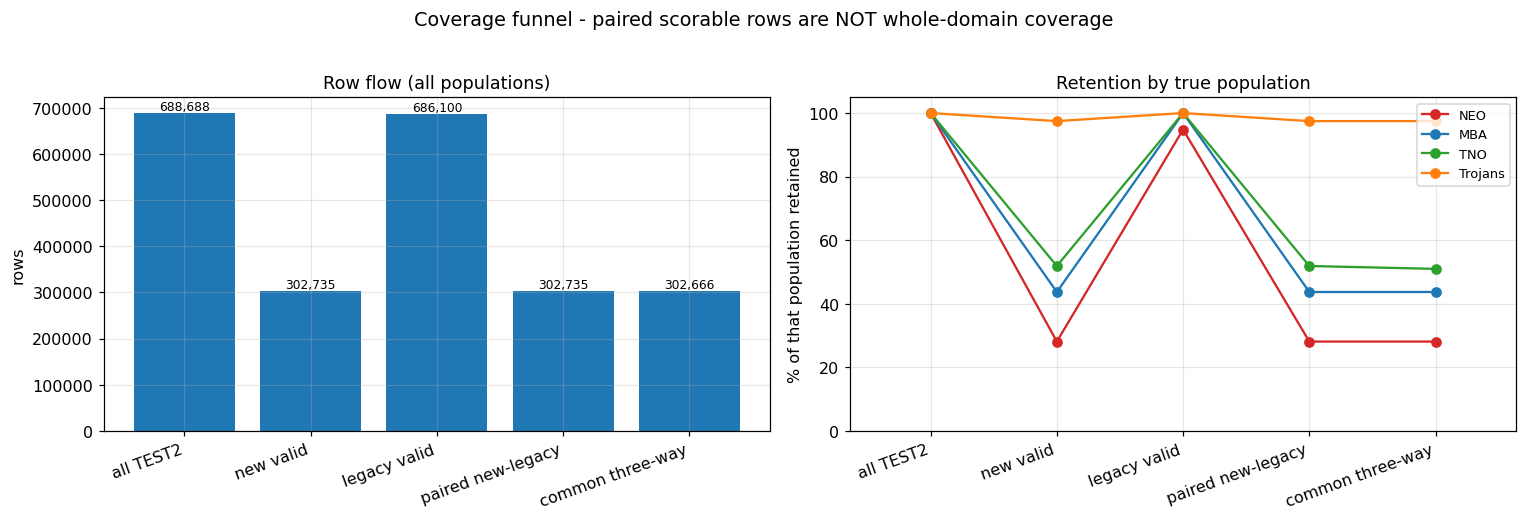

In [13]:
stages = [("all TEST2", np.ones(len(df),bool)),
          ("new valid", m_new),
          ("legacy valid", m_leg),
          ("paired new-legacy", U["PAIRED_NEW_LEGACY"]),
          ("common three-way", U["COMMON_THREEWAY"])]
flow=[]
for nm,mask in stages:
    r = dict(stage=nm, rows=int(mask.sum()), pct_of_all=100*mask.mean(),
             weight=float(w_all[mask].sum()))
    for t in TRUTHS:
        r[t] = int((mask & (df[COL['truth']]==t).to_numpy()).sum())
    flow.append(r)
flow = pd.DataFrame(flow)
print(flow.to_string(index=False, float_format=lambda z: f"{z:12.2f}"))
flow.to_csv(OUT/"row_flow.csv", index=False)

fig, ax = plt.subplots(1,2, figsize=(14,4.6))
x = np.arange(len(flow))
ax[0].bar(x, flow.rows, color="tab:slate" if False else "tab:blue")
for i,v in enumerate(flow.rows): ax[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
ax[0].set_xticks(x); ax[0].set_xticklabels(flow.stage, rotation=20, ha="right")
ax[0].set_ylabel("rows"); ax[0].set_title("Row flow (all populations)")
bot = np.zeros(len(flow))
for t,c in zip(TRUTHS, ("tab:red","tab:blue","tab:green","tab:orange")):
    ax[1].bar(x, 100*flow[t]/flow[t].iloc[0], bottom=None, alpha=0.0)
for t,c in zip(TRUTHS, ("tab:red","tab:blue","tab:green","tab:orange")):
    ax[1].plot(x, 100*flow[t]/flow[t].iloc[0], "o-", color=c, label=t)
ax[1].set_xticks(x); ax[1].set_xticklabels(flow.stage, rotation=20, ha="right")
ax[1].set_ylabel("% of that population retained"); ax[1].set_ylim(0,105)
ax[1].legend(); ax[1].set_title("Retention by true population")
fig.suptitle("Coverage funnel - paired scorable rows are NOT whole-domain coverage", y=1.02)
plt.tight_layout(); plt.savefig(FIG/"01_row_flow.png", dpi=130, bbox_inches="tight"); plt.show()

## Step 7 — where the two score distributions differ

Descriptive only. The known signature is that NEO scores move down substantially under the new
classifier while non-NEO medians barely move; the open question is whether the **non-NEO upper
tail** also moves, since that tail is what sets the top-ranked operating region.

In [14]:
u = U["PAIRED_NEW_LEGACY"]
d = df.loc[u].reset_index(drop=True)
y = y_all[u]; w = w_all[u]
sn = d[COL['new']].to_numpy(float); sl = d[COL['legacy']].to_numpy(float)
pop = d[COL['truth']].to_numpy()

qs = [0.50,0.90,0.95,0.99,0.999]
rows=[]
for t in ["NEO"]+[p for p in TRUTHS if p!="NEO"]:
    mt = pop==t
    if mt.sum()==0: continue
    for nm,sv in (("new",sn),("legacy",sl)):
        r = dict(population=t, classifier=nm, n=int(mt.sum()))
        for q in qs: r[f"q{q}"] = float(np.quantile(sv[mt], q))
        rows.append(r)
qt = pd.DataFrame(rows)
print(qt.to_string(index=False, float_format=lambda z: f"{z:9.5f}"))
qt.to_csv(OUT/"score_quantiles.csv", index=False)
print()
for t in TRUTHS:
    mt = pop==t
    if mt.sum()==0: continue
    dm = np.median(sn[mt])-np.median(sl[mt])
    d99 = np.quantile(sn[mt],0.99)-np.quantile(sl[mt],0.99)
    print(f"  {t:8s} median new-legacy {dm:+8.5f}   99th pct new-legacy {d99:+8.5f}")

population classifier      n      q0.5      q0.9     q0.95     q0.99    q0.999
       NEO        new  14027   0.28035   0.80138   0.86304   0.92818   0.96399
       NEO     legacy  14027   0.50768   0.92686   0.95350   0.97809   0.98872
       MBA        new 268682   0.00055   0.00161   0.00309   0.01556   0.10228
       MBA     legacy 268682   0.00058   0.00180   0.00340   0.01724   0.11942
       TNO        new   3930   0.00002   0.00008   0.00011   0.00022   0.00114
       TNO     legacy   3930   0.00002   0.00010   0.00011   0.00017   0.00132
   Trojans        new  16096   0.00049   0.00116   0.00154   0.00285   0.00575
   Trojans     legacy  16096   0.00054   0.00133   0.00181   0.00329   0.00787

  NEO      median new-legacy -0.22733   99th pct new-legacy -0.04991
  MBA      median new-legacy -0.00003   99th pct new-legacy -0.00168
  TNO      median new-legacy -0.00000   99th pct new-legacy +0.00005
  Trojans  median new-legacy -0.00005   99th pct new-legacy -0.00044


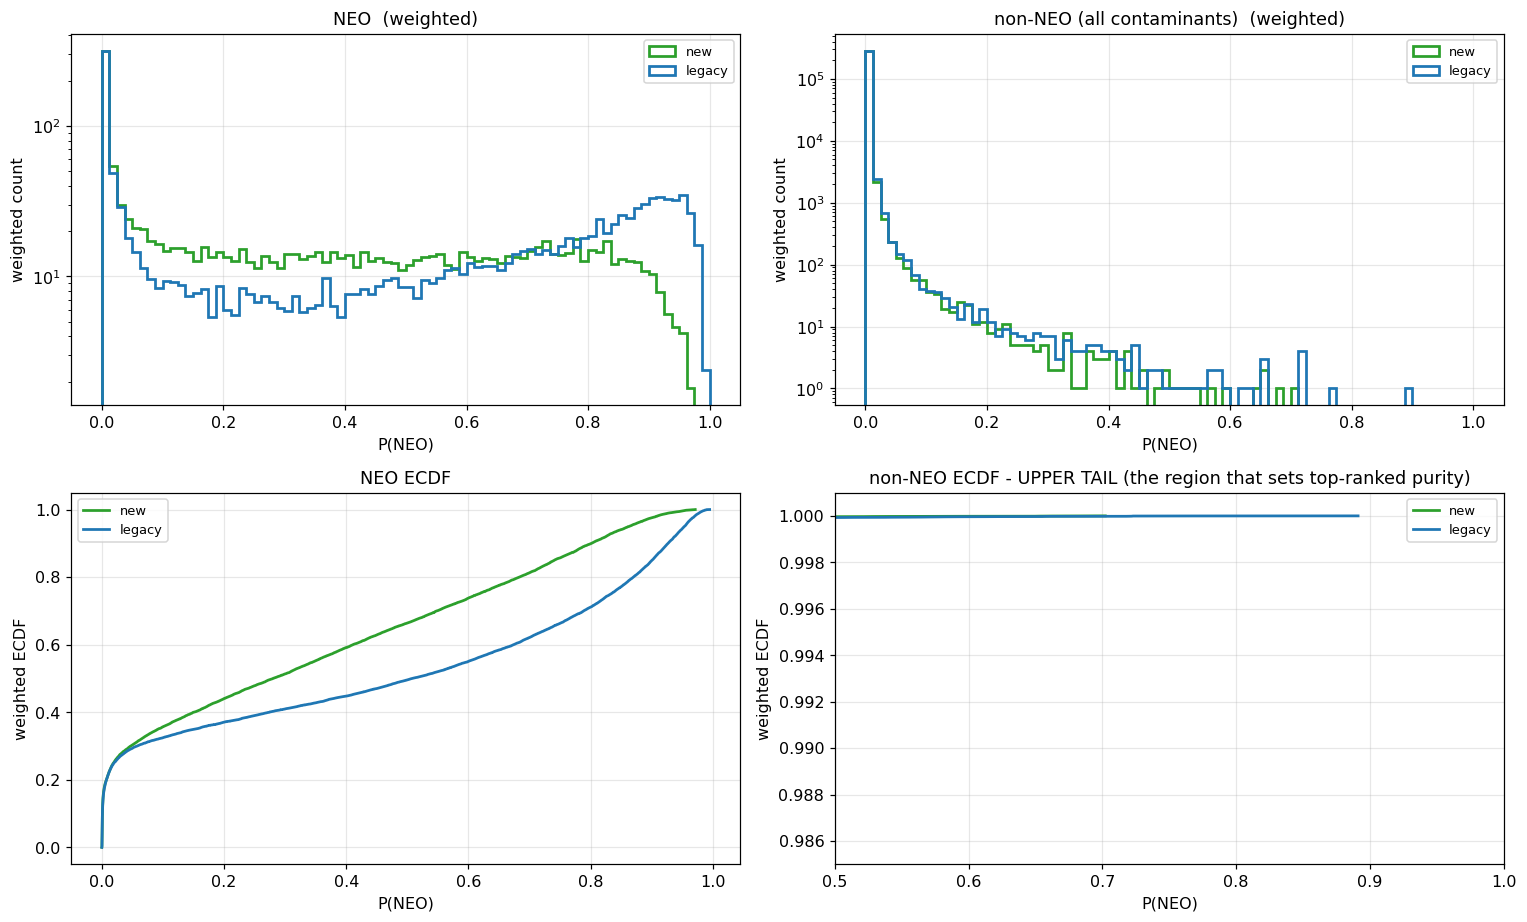

In [15]:
fig, ax = plt.subplots(2,2, figsize=(14,8.5))
bins = np.linspace(0,1,81)
for a_, mt, ttl in ((ax[0,0], y==1, "NEO"), (ax[0,1], y==0, "non-NEO (all contaminants)")):
    a_.hist(sn[mt], bins=bins, weights=w[mt], histtype="step", lw=1.8, color=C_NEW, label="new")
    a_.hist(sl[mt], bins=bins, weights=w[mt], histtype="step", lw=1.8, color=C_LEG, label="legacy")
    a_.set_yscale("log"); a_.set_xlabel("P(NEO)"); a_.set_ylabel("weighted count")
    a_.set_title(f"{ttl}  (weighted)"); a_.legend()
for a_, mt, ttl in ((ax[1,0], y==1, "NEO"), (ax[1,1], y==0, "non-NEO")):
    for sv,nm,c in ((sn,"new",C_NEW),(sl,"legacy",C_LEG)):
        o = np.argsort(sv[mt]); cw = np.cumsum(w[mt][o]); cw = cw/cw[-1]
        a_.plot(sv[mt][o], cw, lw=1.8, color=c, label=nm)
    a_.set_xlabel("P(NEO)"); a_.set_ylabel("weighted ECDF"); a_.set_title(f"{ttl} ECDF"); a_.legend()
ax[1,1].set_xlim(0.5,1.0); ax[1,1].set_ylim(0.985,1.001)
ax[1,1].set_title("non-NEO ECDF - UPPER TAIL (the region that sets top-ranked purity)")
plt.tight_layout(); plt.savefig(FIG/"02_score_distributions.png", dpi=130, bbox_inches="tight"); plt.show()

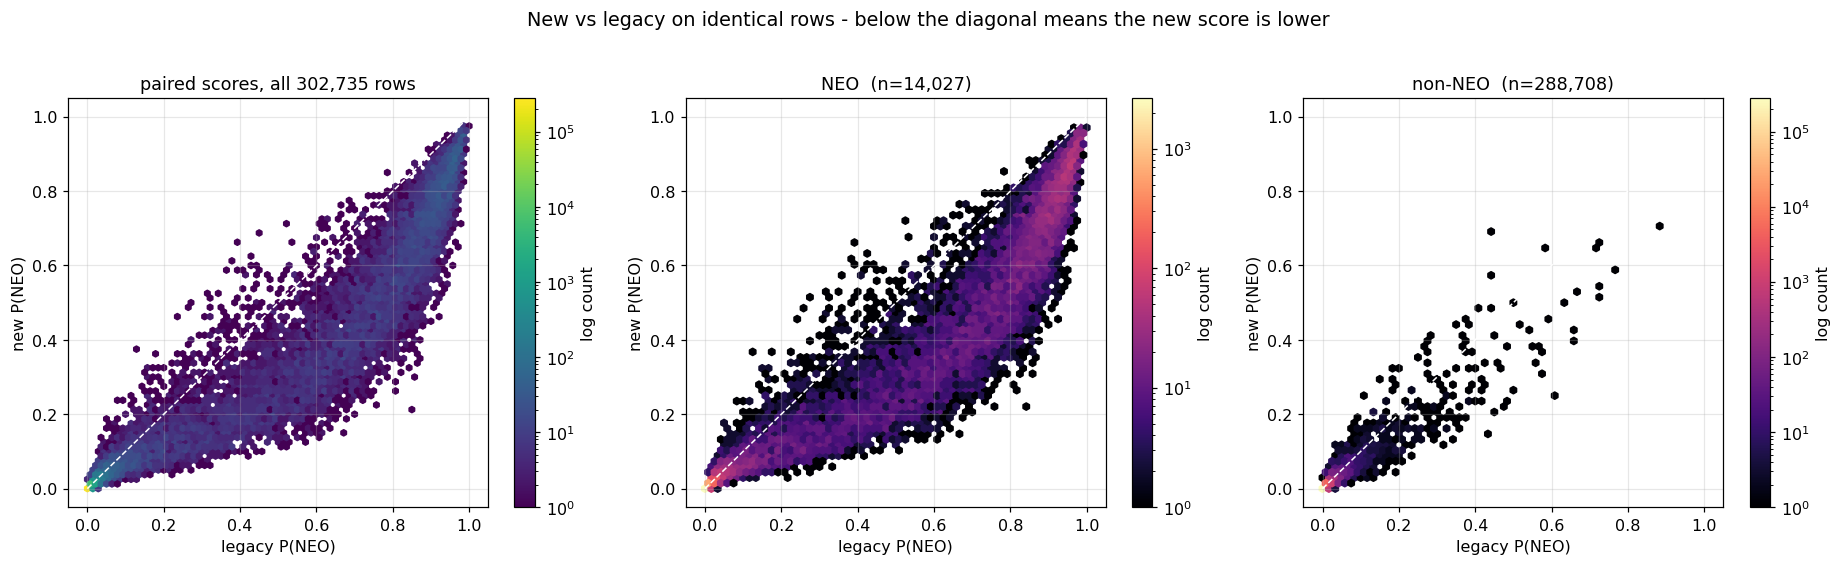

In [16]:
fig, ax = plt.subplots(1,3, figsize=(17,5))
hb = ax[0].hexbin(sl, sn, gridsize=70, bins="log", cmap="viridis", extent=(0,1,0,1))
ax[0].plot([0,1],[0,1],"w--",lw=1)
ax[0].set_xlabel("legacy P(NEO)"); ax[0].set_ylabel("new P(NEO)")
ax[0].set_title(f"paired scores, all {len(d):,} rows"); plt.colorbar(hb, ax=ax[0], label="log count")
for a_, mt, ttl in ((ax[1], y==1, "NEO"), (ax[2], y==0, "non-NEO")):
    h = a_.hexbin(sl[mt], sn[mt], gridsize=60, bins="log", cmap="magma", extent=(0,1,0,1))
    a_.plot([0,1],[0,1],"w--",lw=1); a_.set_xlabel("legacy P(NEO)"); a_.set_ylabel("new P(NEO)")
    a_.set_title(f"{ttl}  (n={int(mt.sum()):,})"); plt.colorbar(h, ax=a_, label="log count")
fig.suptitle("New vs legacy on identical rows - below the diagonal means the new score is lower", y=1.02)
plt.tight_layout(); plt.savefig(FIG/"03_paired_scores.png", dpi=130, bbox_inches="tight"); plt.show()

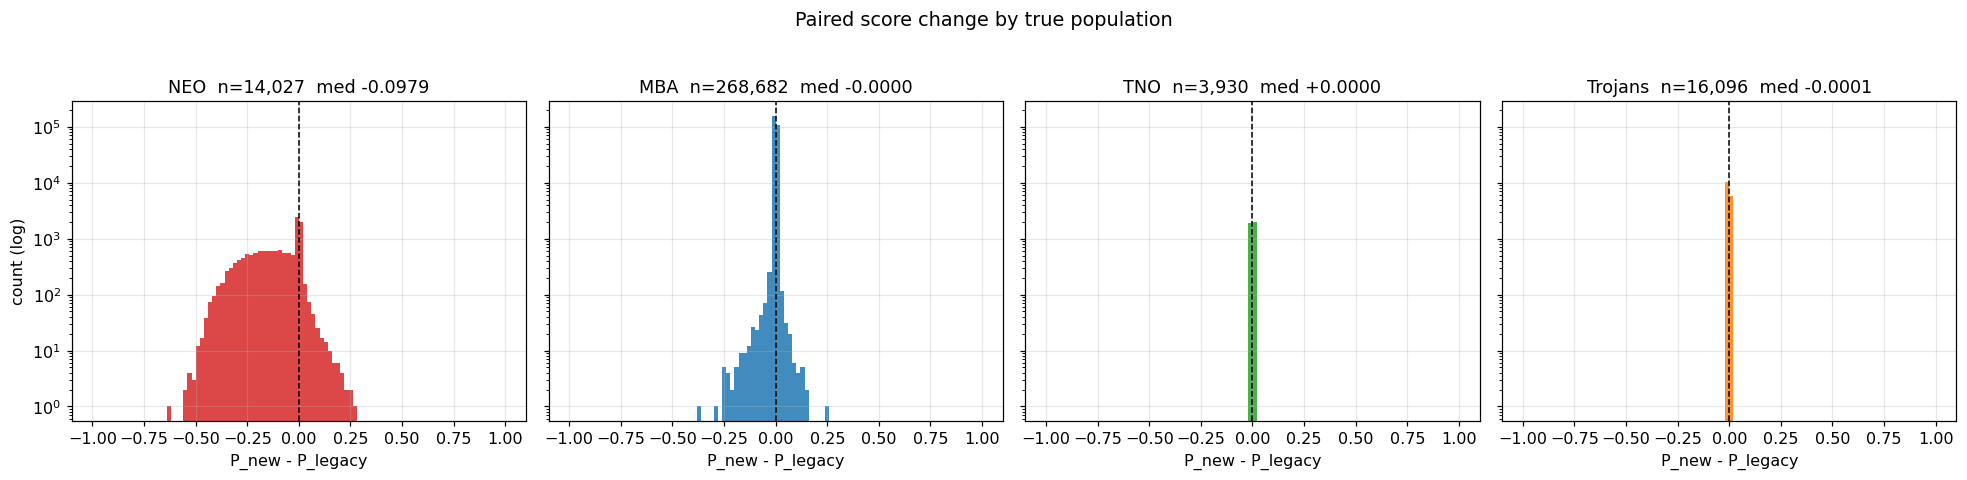

In [17]:
fig, ax = plt.subplots(1,4, figsize=(18,4.2), sharey=True)
bb = np.linspace(-1,1,101)
for a_, t, c in zip(ax, TRUTHS, ("tab:red","tab:blue","tab:green","tab:orange")):
    mt = pop==t
    if mt.sum()==0:
        a_.set_title(f"{t} (none)"); continue
    dd = sn[mt]-sl[mt]
    a_.hist(dd, bins=bb, color=c, alpha=0.85)
    a_.axvline(0, color="k", ls="--", lw=1)
    a_.set_yscale("log"); a_.set_xlabel("P_new - P_legacy")
    a_.set_title(f"{t}  n={int(mt.sum()):,}"
                 f"  med {np.median(dd):+.4f}")
ax[0].set_ylabel("count (log)")
fig.suptitle("Paired score change by true population", y=1.03)
plt.tight_layout(); plt.savefig(FIG/"04_paired_delta.png", dpi=130, bbox_inches="tight"); plt.show()

## Step 8 — the conventional ROC proof

TPR versus FPR. `PAIRED_NEW_LEGACY` for the primary two-way comparison; digest2 appears only on
`COMMON_THREEWAY`, drawn as **discrete attainable points** because its 101 integer levels do not
form a continuous score.

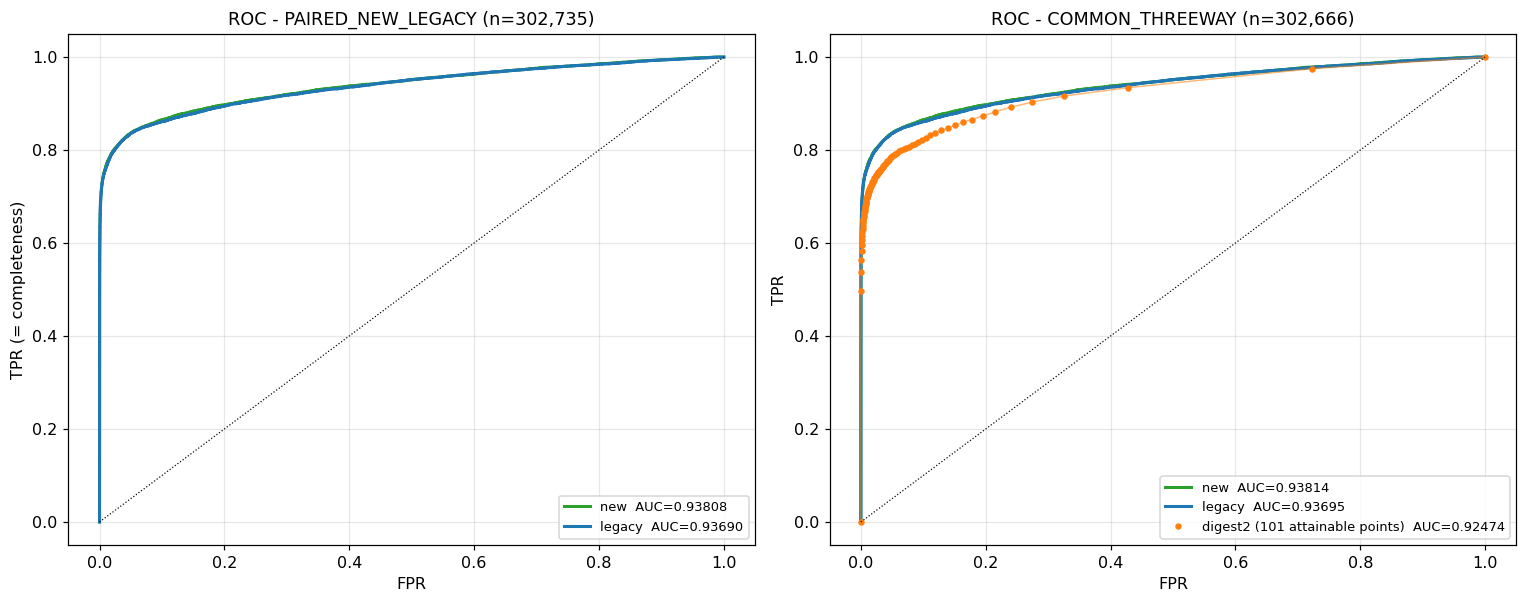

In [18]:
u2 = U["COMMON_THREEWAY"]
d2df = df.loc[u2].reset_index(drop=True)
y2 = y_all[u2]; w2 = w_all[u2]
S2 = {"new": d2df[COL['new']].to_numpy(float), "legacy": d2df[COL['legacy']].to_numpy(float),
      "digest2": d2df[COL['d2']].to_numpy(float)}

fig, ax = plt.subplots(1,2, figsize=(14,5.6))
for nm,sv,c in (("new",sn,C_NEW),("legacy",sl,C_LEG)):
    f_,t_,_ = roc_w(y,sv,w)
    ax[0].plot(f_,t_,lw=2,color=c,label=f"{nm}  AUC={auc_w(y,sv,w):.5f}")
ax[0].plot([0,1],[0,1],"k:",lw=0.8)
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR (= completeness)")
ax[0].set_title(f"ROC - PAIRED_NEW_LEGACY (n={len(d):,})"); ax[0].legend(loc="lower right")
for nm,c in (("new",C_NEW),("legacy",C_LEG)):
    f_,t_,_ = roc_w(y2,S2[nm],w2)
    ax[1].plot(f_,t_,lw=2,color=c,label=f"{nm}  AUC={auc_w(y2,S2[nm],w2):.5f}")
f_,t_,_ = roc_w(y2,S2["digest2"],w2)
ax[1].plot(f_,t_,lw=1.0,color=C_D2,alpha=0.55)
ax[1].plot(f_,t_,"o",ms=3.2,color=C_D2,
           label=f"digest2 (101 attainable points)  AUC={auc_w(y2,S2['digest2'],w2):.5f}")
ax[1].plot([0,1],[0,1],"k:",lw=0.8)
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR")
ax[1].set_title(f"ROC - COMMON_THREEWAY (n={len(d2df):,})"); ax[1].legend(loc="lower right")
plt.tight_layout(); plt.savefig(FIG/"05_roc_full.png", dpi=130, bbox_inches="tight"); plt.show()

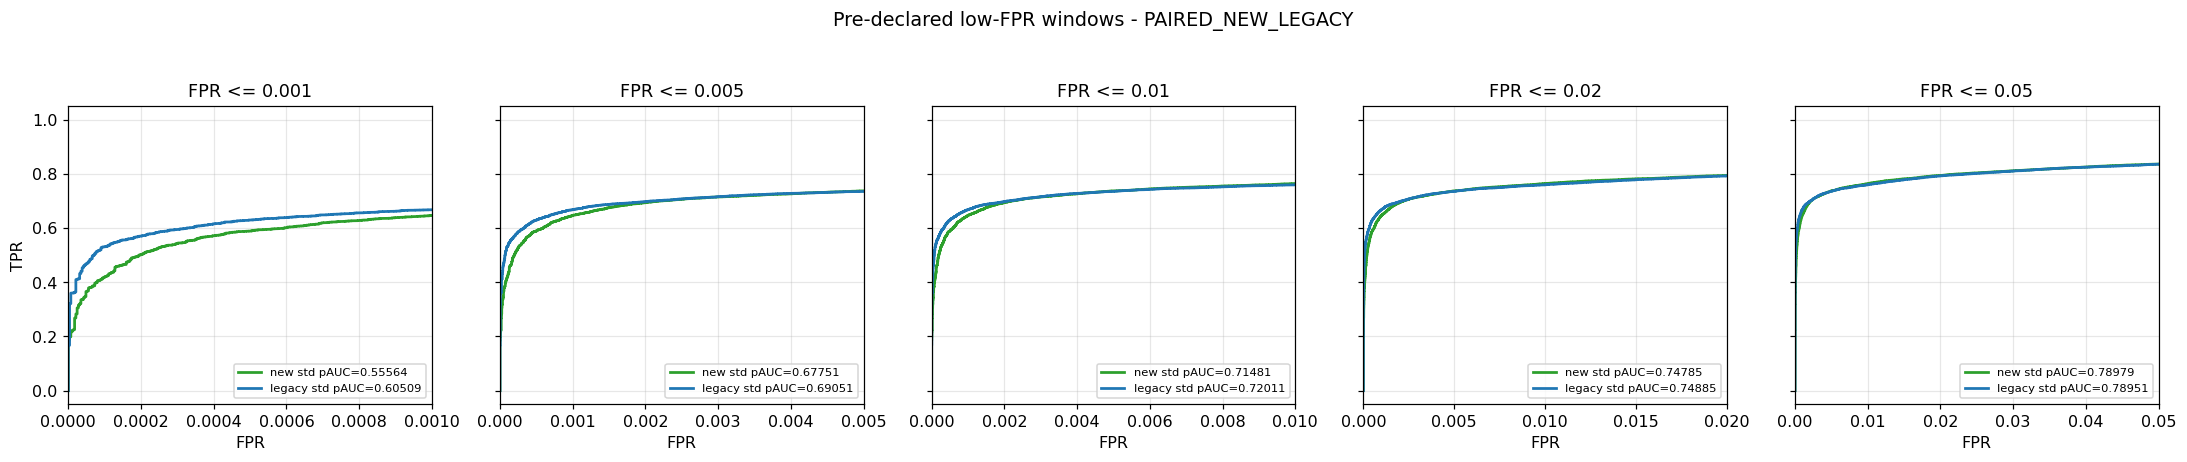

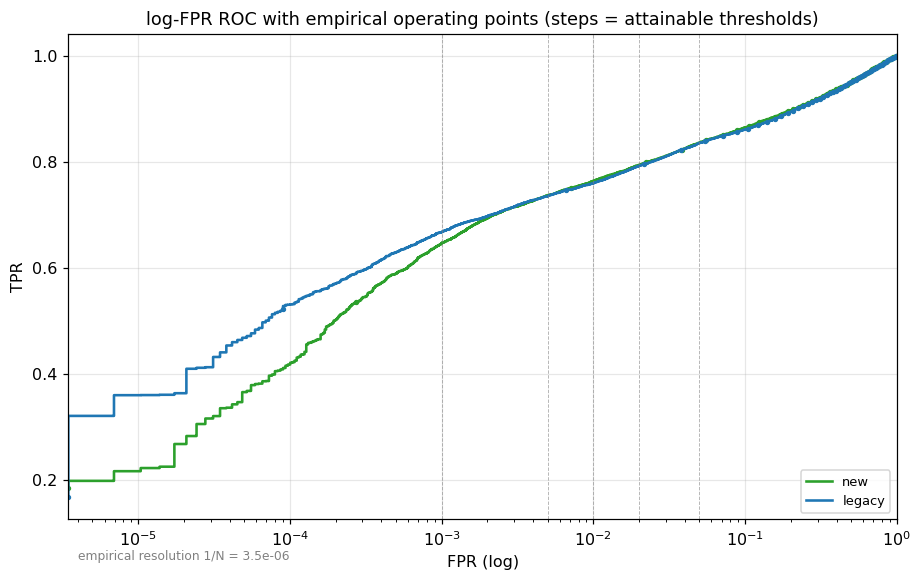

In [19]:
fig, ax = plt.subplots(1,len(FPR_LIMITS), figsize=(20,4.0), sharey=True)
for a_, L in zip(ax, FPR_LIMITS):
    for nm,sv,c in (("new",sn,C_NEW),("legacy",sl,C_LEG)):
        f_,t_,_ = roc_w(y,sv,w)
        a_.plot(f_,t_,lw=1.8,color=c,
                label=f"{nm} std pAUC={pauc_w(y,sv,w,L)[1]:.5f}")
    a_.set_xlim(0,L); a_.set_xlabel("FPR"); a_.legend(loc="lower right", fontsize=7.5)
    a_.set_title(f"FPR <= {L}")
ax[0].set_ylabel("TPR")
fig.suptitle("Pre-declared low-FPR windows - PAIRED_NEW_LEGACY", y=1.04)
plt.tight_layout(); plt.savefig(FIG/"06_roc_lowfpr.png", dpi=130, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(8.5,5.4))
for nm,sv,c in (("new",sn,C_NEW),("legacy",sl,C_LEG)):
    f_,t_,_ = roc_w(y,sv,w)
    keep = f_ >= FPR_FLOOR
    ax.step(f_[keep], t_[keep], where="post", lw=1.7, color=c, label=nm)
    ax.plot(f_[keep][::max(1,keep.sum()//60)], t_[keep][::max(1,keep.sum()//60)],
            "o", ms=2.5, color=c)
ax.set_xscale("log"); ax.set_xlim(FPR_FLOOR, 1.0)
ax.axvline(FPR_FLOOR, color="grey", ls=":", lw=1)
ax.text(FPR_FLOOR*1.15, 0.05, f"empirical resolution 1/N = {FPR_FLOOR:.1e}", fontsize=8, color="grey")
for L in FPR_LIMITS: ax.axvline(L, color="grey", ls="--", lw=0.6, alpha=0.6)
ax.set_xlabel("FPR (log)"); ax.set_ylabel("TPR")
ax.set_title("log-FPR ROC with empirical operating points (steps = attainable thresholds)")
ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(FIG/"07_roc_logfpr.png", dpi=130, bbox_inches="tight"); plt.show()

## Step 9 — the direct difference curve

`TPR_new - TPR_legacy` on a common FPR grid, with a paired bootstrap band.

    below zero  -> legacy better
    above zero  -> new better
    near zero   -> tied

This is the single most direct test of whether the difference is **localized at low FPR** or
**extends across the range**. The paired bootstrap that produces the band is computed here once and
reused for the interval table in Step 12.

In [20]:
FPR_GRID = np.unique(np.concatenate([
    np.logspace(np.log10(FPR_FLOOR), 0.0, 200), np.array(FPR_LIMITS)]))

def metric_pack(y_, s_, w_):
    out = {}
    fpr, tpr, _ = roc_w(y_, s_, w_)
    out["auc"] = float(np.trapezoid(tpr, fpr))
    for L in FPR_LIMITS:
        m = fpr <= L                                    # FROZEN convention, matches the seal
        if m.sum() < 2:
            raw = 0.0
        else:
            f = np.concatenate([[0.0], fpr[m]]); t = np.concatenate([[0.0], tpr[m]])
            raw = float(np.trapezoid(t, f))
        out[f"pauc_raw@{L}"] = raw
        out[f"pauc_std@{L}"] = raw/L
        out[f"tpr@fpr{L}"]   = float(np.interp(L, fpr, tpr))
    out["_grid"] = np.interp(FPR_GRID, fpr, tpr)
    pc = precision_at_completeness(y_, s_, w_, COMPLETENESS_TARGETS)
    for c,(pr,_a,_t) in pc.items(): out[f"prec@compl{c}"] = pr
    cc = completeness_at_contamination(y_, s_, w_, CONTAMINATION_TARGETS)
    for c,(co,_a,_t) in cc.items(): out[f"compl@contam{c}"] = co
    return out

POINT = {"new": metric_pack(y, sn, w), "legacy": metric_pack(y, sl, w)}
DELTA_POINT = {k: POINT["new"][k]-POINT["legacy"][k] for k in POINT["new"] if k != "_grid"}
DGRID_POINT = POINT["new"]["_grid"] - POINT["legacy"]["_grid"]
print(f"point estimate  delta AUC = {DELTA_POINT['auc']:+.6f}")
for L in FPR_LIMITS:
    print(f"  delta std pAUC (FPR<={L:<5}) {DELTA_POINT[f'pauc_std@{L}']:+.6f}"
          f"   delta TPR@FPR={L:<5} {DELTA_POINT[f'tpr@fpr{L}']:+.6f}")

point estimate  delta AUC = +0.001188
  delta std pAUC (FPR<=0.001) -0.049450   delta TPR@FPR=0.001 -0.020888
  delta std pAUC (FPR<=0.005) -0.013001   delta TPR@FPR=0.005 +0.002067
  delta std pAUC (FPR<=0.01 ) -0.005308   delta TPR@FPR=0.01  +0.004563
  delta std pAUC (FPR<=0.02 ) -0.001003   delta TPR@FPR=0.02  +0.001640
  delta std pAUC (FPR<=0.05 ) +0.000275   delta TPR@FPR=0.05  +0.000499


In [21]:
# ---- paired stratified bootstrap (rows keep their new/legacy pairing) --------------
N_BOOT = 500
rng = np.random.default_rng(SEED)
idx_neo = np.where(y==1)[0]; idx_non = np.where(y==0)[0]
print(f"bootstrap unit: {'source parent' if PARENT_CLUSTERED else 'row, stratified by truth population'}")
print(f"  (tracklets per parent = 1.000, so parent and row resampling coincide)")
print(f"replicates {N_BOOT}   NEO {len(idx_neo):,}   non-NEO {len(idx_non):,}   seed {SEED}")

keys = [k for k in POINT["new"] if k != "_grid"]
boot = {k: np.empty(N_BOOT) for k in keys}
boot_grid = np.empty((N_BOOT, len(FPR_GRID)))
t0 = time.time()
for b in range(N_BOOT):
    sel = np.concatenate([rng.choice(idx_neo, idx_neo.size, replace=True),
                          rng.choice(idx_non, idx_non.size, replace=True)])
    yb, wb = y[sel], w[sel]
    pn = metric_pack(yb, sn[sel], wb); pl = metric_pack(yb, sl[sel], wb)
    for k in keys: boot[k][b] = pn[k]-pl[k]
    boot_grid[b] = pn["_grid"]-pl["_grid"]
    if (b+1) % 100 == 0:
        print(f"  {b+1}/{N_BOOT}  ({time.time()-t0:.0f}s)")
print(f"bootstrap done in {time.time()-t0:.0f}s")

bootstrap unit: row, stratified by truth population
  (tracklets per parent = 1.000, so parent and row resampling coincide)
replicates 500   NEO 14,027   non-NEO 288,708   seed 20260824


  100/500  (27s)


  200/500  (55s)


  300/500  (82s)


  400/500  (110s)


  500/500  (137s)
bootstrap done in 137s


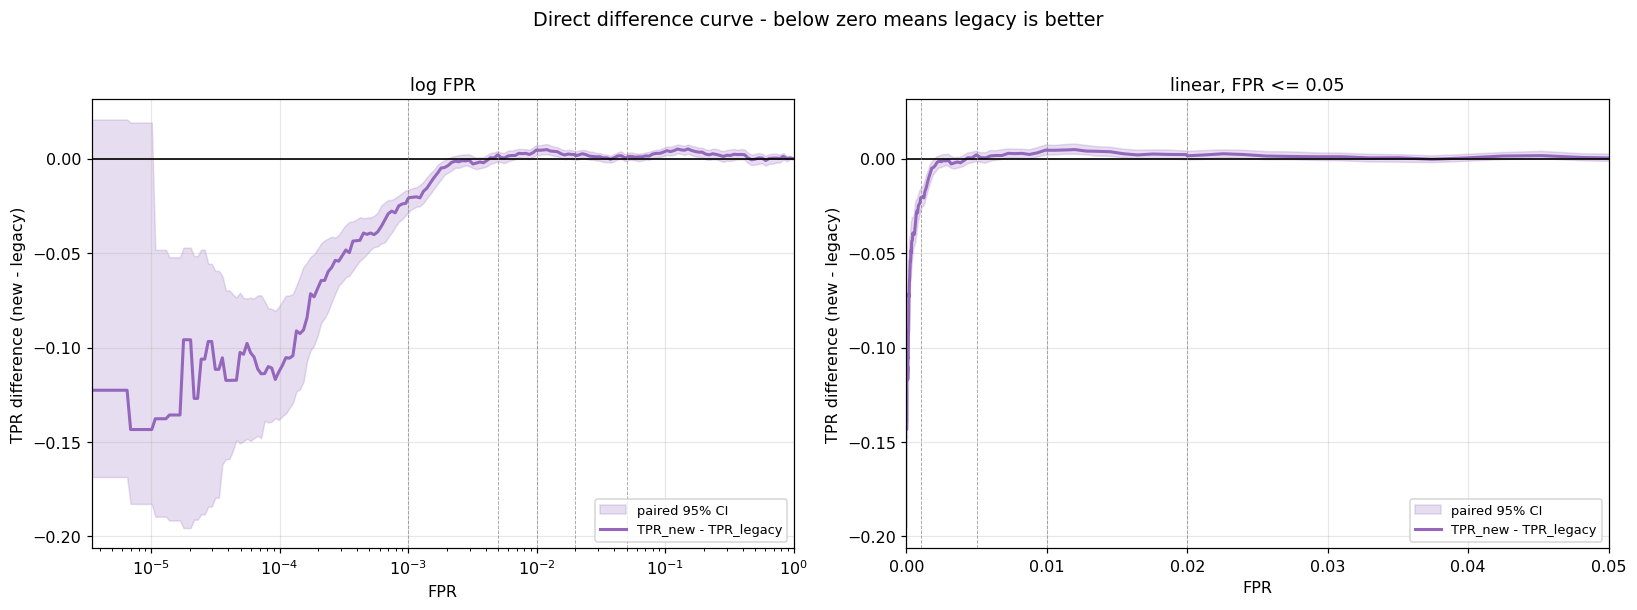

      FPR  delta_TPR     ci_lo     ci_hi  frac_favouring_legacy  excludes_zero                              note
+0.001000  -0.020888 -0.028516 -0.016465              +1.000000           True TPR interpolated at the fixed FPR
+0.005000  +0.002067 -0.001501 +0.003958              +0.150000          False TPR interpolated at the fixed FPR
+0.010000  +0.004563 +0.001959 +0.007272              +0.000000           True TPR interpolated at the fixed FPR
+0.020000  +0.001640 -0.000499 +0.003992              +0.056000          False TPR interpolated at the fixed FPR
+0.050000  +0.000499 -0.001321 +0.002533              +0.254000          False TPR interpolated at the fixed FPR


In [22]:
lo = np.percentile(boot_grid, 2.5, axis=0); hi = np.percentile(boot_grid, 97.5, axis=0)
fig, ax = plt.subplots(1,2, figsize=(15,5.4))
for a_, xlog in ((ax[0], True), (ax[1], False)):
    a_.fill_between(FPR_GRID, lo, hi, color="tab:purple", alpha=0.22, label="paired 95% CI")
    a_.plot(FPR_GRID, DGRID_POINT, lw=2, color="tab:purple", label="TPR_new - TPR_legacy")
    a_.axhline(0, color="k", lw=1.1, ls="-")
    for L in FPR_LIMITS: a_.axvline(L, color="grey", ls="--", lw=0.6, alpha=0.7)
    a_.set_xlabel("FPR"); a_.set_ylabel("TPR difference (new - legacy)")
    if xlog:
        a_.set_xscale("log"); a_.set_xlim(FPR_FLOOR, 1.0); a_.set_title("log FPR")
    else:
        a_.set_xlim(0, 0.05); a_.set_title("linear, FPR <= 0.05")
    a_.legend(loc="lower right")
fig.suptitle("Direct difference curve - below zero means legacy is better", y=1.02)
plt.tight_layout(); plt.savefig(FIG/"08_delta_tpr.png", dpi=130, bbox_inches="tight"); plt.show()

rows=[]
for L in FPR_LIMITS:
    b = boot[f"tpr@fpr{L}"]
    rows.append(dict(FPR=L, delta_TPR=DELTA_POINT[f"tpr@fpr{L}"],
                     ci_lo=np.percentile(b,2.5), ci_hi=np.percentile(b,97.5),
                     frac_favouring_legacy=float((b<0).mean()),
                     excludes_zero=bool(np.percentile(b,2.5)>0 or np.percentile(b,97.5)<0),
                     note="TPR interpolated at the fixed FPR"))
fpr_ops = pd.DataFrame(rows)
print(fpr_ops.to_string(index=False, float_format=lambda z: f"{z:+.6f}"))
fpr_ops.to_csv(OUT/"fpr_operating_points.csv", index=False)

## Step 10 — completeness vs contamination (**NOT an ROC**)

Old house style from `mag245_nbody_benchmark_vs_sorcha_roc.ipynb` — completeness on x, contamination
on y, both in percent. That notebook called these panels "ROC"; they are not. Only attainable
operating points are drawn, so no cosmetic smoothing invents a threshold that cannot be reached.

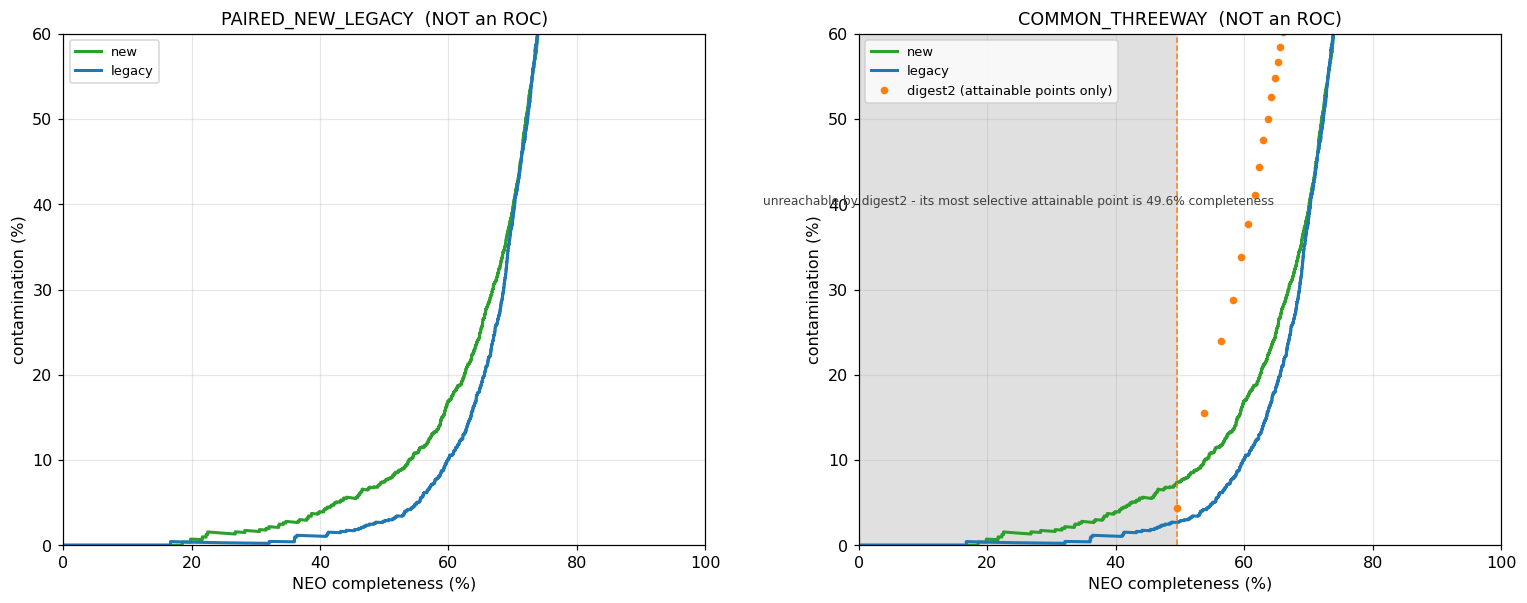

In [23]:
fig, ax = plt.subplots(1,2, figsize=(14,5.6))
for nm,sv,c in (("new",sn,C_NEW),("legacy",sl,C_LEG)):
    comp,prec,cont,thr = pr_curve_w(y,sv,w)
    ax[0].plot(100*comp, 100*cont, lw=2, color=c, label=nm)
ax[0].set_xlim(0,100); ax[0].set_ylim(0,60)
ax[0].set_xlabel("NEO completeness (%)"); ax[0].set_ylabel("contamination (%)")
ax[0].set_title("PAIRED_NEW_LEGACY  (NOT an ROC)"); ax[0].legend(loc="upper left")
for nm,c in (("new",C_NEW),("legacy",C_LEG)):
    comp,prec,cont,thr = pr_curve_w(y2,S2[nm],w2)
    ax[1].plot(100*comp, 100*cont, lw=2, color=c, label=nm)
comp,prec,cont,thr = pr_curve_w(y2,S2["digest2"],w2)
ax[1].plot(100*comp, 100*cont, "o", ms=4, color=C_D2, label="digest2 (attainable points only)")
cmin = 100*comp[0]
ax[1].axvspan(0, cmin, color="0.88", zorder=0)
ax[1].axvline(cmin, color=C_D2, ls="--", lw=1)
ax[1].text(cmin/2, 40, f"unreachable by digest2 - its most selective "
           f"attainable point is {cmin:.1f}% completeness",
           ha="center", fontsize=8, color="0.25")
ax[1].set_xlim(0,100); ax[1].set_ylim(0,60)
ax[1].set_xlabel("NEO completeness (%)"); ax[1].set_ylabel("contamination (%)")
ax[1].set_title("COMMON_THREEWAY  (NOT an ROC)"); ax[1].legend(loc="upper left")
plt.tight_layout(); plt.savefig(FIG/"09_completeness_contamination.png", dpi=130, bbox_inches="tight"); plt.show()

In [24]:
EXPECT_PREC = {0.20:(0.9929,0.9964), 0.30:(0.9836,0.9976),
               0.40:(0.9606,0.9894), 0.50:(0.9261,0.9723)}
rows=[]
pc_n = precision_at_completeness(y2,S2["new"],w2,COMPLETENESS_TARGETS)
pc_l = precision_at_completeness(y2,S2["legacy"],w2,COMPLETENESS_TARGETS)
pp_n = precision_at_completeness(y,sn,w,COMPLETENESS_TARGETS)
pp_l = precision_at_completeness(y,sl,w,COMPLETENESS_TARGETS)
for c in COMPLETENESS_TARGETS:
    en, el = EXPECT_PREC[c]
    rows.append(dict(completeness=c,
                     new_COMMON=pc_n[c][0], expected_new=en, new_ok=abs(pc_n[c][0]-en)<=5e-4,
                     legacy_COMMON=pc_l[c][0], expected_legacy=el, legacy_ok=abs(pc_l[c][0]-el)<=5e-4,
                     new_PAIRED=pp_n[c][0], legacy_PAIRED=pp_l[c][0],
                     achieved_completeness_new=pp_n[c][1], threshold_new=pp_n[c][2],
                     threshold_legacy=pp_l[c][2]))
prec_tab = pd.DataFrame(rows)
print("PRECISION AT FIXED COMPLETENESS (attainable points; thresholds shown)")
print(prec_tab.to_string(index=False, float_format=lambda z: f"{z:9.5f}"))
print()
cc_n = completeness_at_contamination(y,sn,w,CONTAMINATION_TARGETS)
cc_l = completeness_at_contamination(y,sl,w,CONTAMINATION_TARGETS)
rows2=[]
for c in CONTAMINATION_TARGETS:
    rows2.append(dict(contamination=c, new_completeness=cc_n[c][0], new_achieved_contam=cc_n[c][1],
                      new_threshold=cc_n[c][2], legacy_completeness=cc_l[c][0],
                      legacy_achieved_contam=cc_l[c][1], legacy_threshold=cc_l[c][2],
                      delta=cc_n[c][0]-cc_l[c][0]))
cont_tab = pd.DataFrame(rows2)
print("COMPLETENESS AT FIXED CONTAMINATION")
print(cont_tab.to_string(index=False, float_format=lambda z: f"{z:9.5f}"))
prec_tab.to_csv(OUT/"completeness_operating_points.csv", index=False)
cont_tab.to_csv(OUT/"contamination_operating_points.csv", index=False)

PRECISION AT FIXED COMPLETENESS (attainable points; thresholds shown)
 completeness  new_COMMON  expected_new  new_ok  legacy_COMMON  expected_legacy  legacy_ok  new_PAIRED  legacy_PAIRED  achieved_completeness_new  threshold_new  threshold_legacy
      0.20000     0.99292       0.99290    True        0.99645          0.99640       True     0.99292        0.99645                    0.20004        0.68321           0.87017
      0.30000     0.98364       0.98360    True        0.99763          0.99760       True     0.98364        0.99763                    0.30006        0.54862           0.78866
      0.40000     0.96062       0.96060    True        0.98942          0.98940       True     0.96062        0.98942                    0.40001        0.41115           0.67384
      0.50000     0.92605       0.92610    True        0.97227          0.97230       True     0.92606        0.97228                    0.50004        0.28035           0.50768

COMPLETENESS AT FIXED CONTAMINATION
 co

## Step 11 — the top-ranked candidate sets

What a follow-up queue would actually contain.

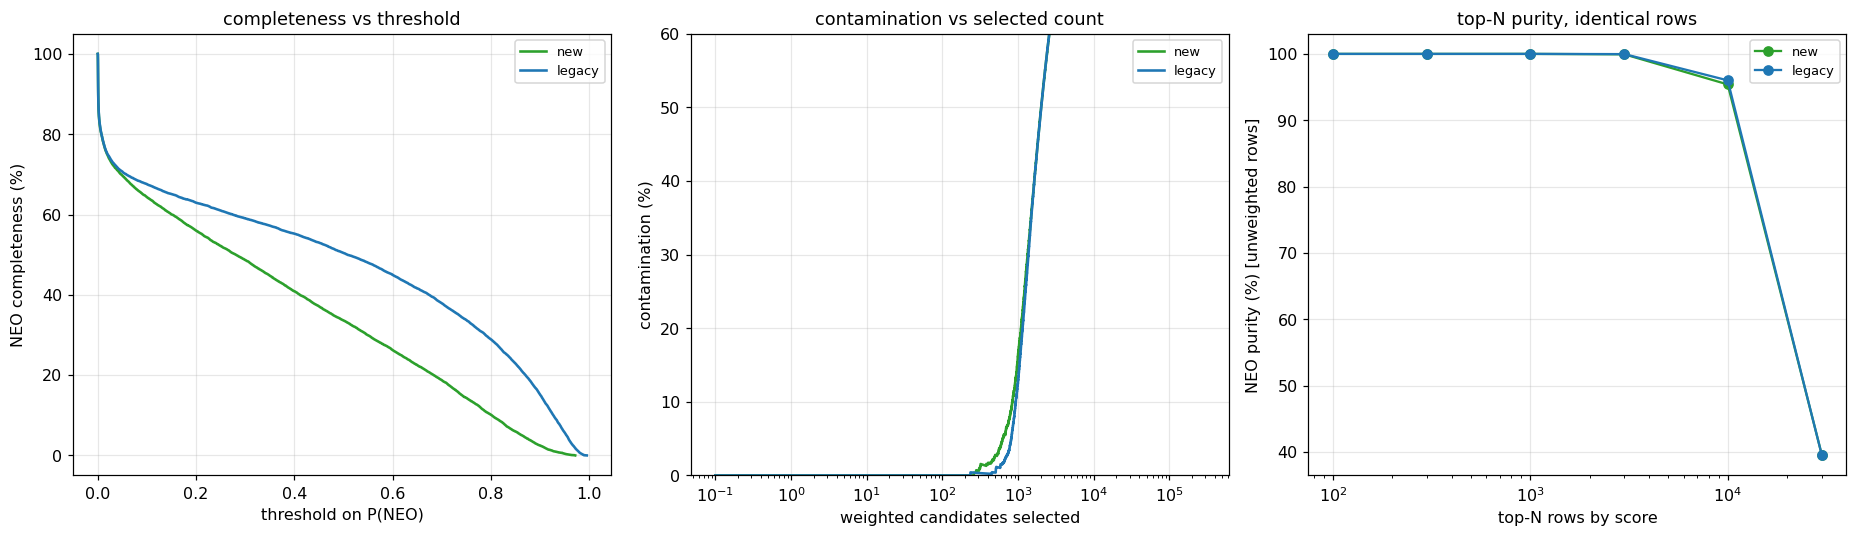

                n_NEO              purity         
classifier     legacy        new   legacy      new
top_n                                             
100          100.0000   100.0000   1.0000   1.0000
300          300.0000   300.0000   1.0000   1.0000
1000        1000.0000  1000.0000   1.0000   1.0000
3000        2999.0000  2998.0000   0.9997   0.9993
10000       9601.0000  9540.0000   0.9601   0.9540
30000      11848.0000 11860.0000   0.3949   0.3953


In [25]:
fig, ax = plt.subplots(1,3, figsize=(17,5))
for nm,sv,c in (("new",sn,C_NEW),("legacy",sl,C_LEG)):
    comp,prec,cont,thr = pr_curve_w(y,sv,w)
    o = np.argsort(-sv, kind="mergesort")
    ww = w[o]; sel_w = np.cumsum(ww)
    keep = np.concatenate([np.diff(sv[o])!=0,[True]])
    ax[0].plot(thr, comp*100, lw=1.7, color=c, label=nm)
    ax[1].plot(sel_w[keep], 100*cont, lw=1.7, color=c, label=nm)
ax[0].set_xlabel("threshold on P(NEO)"); ax[0].set_ylabel("NEO completeness (%)")
ax[0].set_title("completeness vs threshold"); ax[0].legend()
ax[1].set_xscale("log"); ax[1].set_xlabel("weighted candidates selected")
ax[1].set_ylabel("contamination (%)"); ax[1].set_ylim(0,60)
ax[1].set_title("contamination vs selected count"); ax[1].legend()

TOPN = [100, 300, 1000, 3000, 10000, 30000]
rows=[]
for nm,sv in (("new",sn),("legacy",sl)):
    o = np.argsort(-sv, kind="mergesort")
    for n_ in TOPN:
        sl_ = o[:n_]
        n_neo = int((y[sl_]==1).sum())
        rows.append(dict(classifier=nm, top_n=n_, n_NEO=n_neo,
                         purity=n_neo/n_, recall=n_neo/int((y==1).sum())))
top = pd.DataFrame(rows)
pv = top.pivot(index="top_n", columns="classifier", values="purity")
ax[2].plot(pv.index, 100*pv["new"], "o-", color=C_NEW, label="new")
ax[2].plot(pv.index, 100*pv["legacy"], "o-", color=C_LEG, label="legacy")
ax[2].set_xscale("log"); ax[2].set_xlabel("top-N rows by score")
ax[2].set_ylabel("NEO purity (%) [unweighted rows]"); ax[2].set_title("top-N purity, identical rows")
ax[2].legend()
plt.tight_layout(); plt.savefig(FIG/"10_top_ranked.png", dpi=130, bbox_inches="tight"); plt.show()
print(top.pivot(index="top_n",columns="classifier",values=["n_NEO","purity"]).to_string(
      float_format=lambda z: f"{z:8.4f}"))

In [26]:
rows=[]
for nm,sv in (("new",sn),("legacy",sl)):
    o = np.argsort(-sv, kind="mergesort")
    for n_ in (1000, 10000):
        sl_ = o[:n_]; comp_pop = pd.Series(pop[sl_]).value_counts()
        r = dict(classifier=nm, top_n=n_)
        for t in TRUTHS: r[t] = int(comp_pop.get(t,0))
        rows.append(r)
comp_tab = pd.DataFrame(rows)
print("CONTAMINANT COMPOSITION OF THE TOP-RANKED SETS")
print(comp_tab.to_string(index=False))
print()
nb_top = 10000
for nm,sv in (("new",sn),("legacy",sl)):
    o = np.argsort(-sv, kind="mergesort")[:nb_top]
    print(f"  {nm:7s} top {nb_top:,}: NEO {int((y[o]==1).sum()):,}  "
          f"contaminants {int((y[o]==0).sum()):,}")

CONTAMINANT COMPOSITION OF THE TOP-RANKED SETS
classifier  top_n  NEO  MBA  TNO  Trojans
       new   1000 1000    0    0        0
       new  10000 9540  460    0        0
    legacy   1000 1000    0    0        0
    legacy  10000 9601  399    0        0

  new     top 10,000: NEO 9,540  contaminants 460
  legacy  top 10,000: NEO 9,601  contaminants 399


## Step 12 — paired uncertainty

Same resampled rows for both classifiers, so every replicate is a genuine paired comparison. Unit is
the source parent where tracklets cluster; here parents map 1:1 to tracklets, so this is a
row-level bootstrap stratified by truth population.

In [27]:
def summarise(name, b, point):
    return dict(metric=name, point=point, ci_lo=float(np.percentile(b,2.5)),
                median=float(np.percentile(b,50)), ci_hi=float(np.percentile(b,97.5)),
                frac_favouring_legacy=float((b<0).mean()),
                excludes_zero=bool(np.percentile(b,2.5)>0 or np.percentile(b,97.5)<0))
rows=[summarise("delta AUC", boot["auc"], DELTA_POINT["auc"])]
for L in FPR_LIMITS:
    rows.append(summarise(f"delta raw pAUC (FPR<={L})", boot[f"pauc_raw@{L}"], DELTA_POINT[f"pauc_raw@{L}"]))
    rows.append(summarise(f"delta std pAUC (FPR<={L})", boot[f"pauc_std@{L}"], DELTA_POINT[f"pauc_std@{L}"]))
    rows.append(summarise(f"delta TPR @ FPR={L}", boot[f"tpr@fpr{L}"], DELTA_POINT[f"tpr@fpr{L}"]))
for c in COMPLETENESS_TARGETS:
    rows.append(summarise(f"delta precision @ completeness={c}", boot[f"prec@compl{c}"],
                          DELTA_POINT[f"prec@compl{c}"]))
for c in CONTAMINATION_TARGETS:
    rows.append(summarise(f"delta completeness @ contamination={c}", boot[f"compl@contam{c}"],
                          DELTA_POINT[f"compl@contam{c}"]))
bi = pd.DataFrame(rows)
bi["verdict"] = np.where(~bi.excludes_zero, "tied",
                 np.where(bi.point < 0, "LEGACY better", "new better"))
print(f"paired bootstrap, {N_BOOT} replicates, seed {SEED}, all deltas are new minus legacy")
print(bi.to_string(index=False, float_format=lambda z: f"{z:+.6f}"))
bi.to_csv(OUT/"bootstrap_intervals.csv", index=False)

paired bootstrap, 500 replicates, seed 20260824, all deltas are new minus legacy
                                 metric     point     ci_lo    median     ci_hi  frac_favouring_legacy  excludes_zero       verdict
                              delta AUC +0.001188 +0.000011 +0.001210 +0.002324              +0.020000           True    new better
            delta raw pAUC (FPR<=0.001) -0.000049 -0.000059 -0.000049 -0.000041              +1.000000           True LEGACY better
            delta std pAUC (FPR<=0.001) -0.049450 -0.059228 -0.049411 -0.040772              +1.000000           True LEGACY better
                  delta TPR @ FPR=0.001 -0.020888 -0.028516 -0.021958 -0.016465              +1.000000           True LEGACY better
            delta raw pAUC (FPR<=0.005) -0.000065 -0.000078 -0.000066 -0.000051              +1.000000           True LEGACY better
            delta std pAUC (FPR<=0.005) -0.013001 -0.015653 -0.013115 -0.010145              +1.000000           True LEGACY be

## Step 13 — descriptive stratification appendix

Existing columns only. Cells below the minimum class counts are marked insufficient rather than
producing an unstable AUC. This is **not** the 5x5 direction mosaic — that is the next task.

In [28]:
MIN_PER_CLASS = 30
strat_rows=[]
speed = np.hypot(d[COL['vlam']].to_numpy(float), d[COL['vbeta']].to_numpy(float))
strata = {
 "apparent V": pd.cut(d[COL['mag']], [14,20,22,23,24,25]),
 "|v| deg/day": pd.cut(speed, [0,0.25,0.5,1.0,2.0,5.0]),
 "|ecliptic lat| deg": pd.cut(d[COL['beta']].abs(), [0,5,15,30,90]),
 "|antisolar lon| deg": pd.cut(d[COL['dlon']].abs(), [0,20,40,70,110,141]),
}
for sname, sv in strata.items():
    for g_, idx in pd.Series(range(len(d))).groupby(sv, observed=True):
        i = idx.to_numpy(); yy=y[i]; ww=w[i]
        n_pos, n_neg = int((yy==1).sum()), int((yy==0).sum())
        if n_pos < MIN_PER_CLASS or n_neg < MIN_PER_CLASS:
            strat_rows.append(dict(stratum=sname, bin=str(g_), n=len(i), n_NEO=n_pos,
                                   auc_new=np.nan, auc_legacy=np.nan, delta_auc=np.nan,
                                   note="insufficient counts")); continue
        an = auc_w(yy, sn[i], ww); al = auc_w(yy, sl[i], ww)
        strat_rows.append(dict(stratum=sname, bin=str(g_), n=len(i), n_NEO=n_pos,
                               auc_new=an, auc_legacy=al, delta_auc=an-al, note=""))
# by contaminant population: NEO vs one contaminant at a time
for t in [p for p in TRUTHS if p!="NEO"]:
    i = np.where((pop==t) | (y==1))[0]; yy=y[i]; ww=w[i]
    if (yy==1).sum() >= MIN_PER_CLASS and (yy==0).sum() >= MIN_PER_CLASS:
        an=auc_w(yy,sn[i],ww); al=auc_w(yy,sl[i],ww)
        strat_rows.append(dict(stratum="NEO vs single contaminant", bin=t, n=len(i),
                               n_NEO=int((yy==1).sum()), auc_new=an, auc_legacy=al,
                               delta_auc=an-al, note=""))
st = pd.DataFrame(strat_rows)
print(st.to_string(index=False, float_format=lambda z: f"{z:8.5f}"))
st.to_csv(OUT/"stratification.csv", index=False)

                  stratum         bin      n  n_NEO  auc_new  auc_legacy  delta_auc                note
               apparent V    (20, 22]  19803    552  0.94210     0.94113    0.00097                    
               apparent V    (22, 23]  43534   1491  0.94219     0.94136    0.00082                    
               apparent V    (23, 24]  85082   3404  0.92873     0.92725    0.00148                    
               apparent V    (24, 25] 154316   8580  0.93739     0.93666    0.00073                    
              |v| deg/day (0.0, 0.25] 122051   1393  0.73464     0.72400    0.01064                    
              |v| deg/day (0.25, 0.5] 161517   2391  0.82048     0.81965    0.00083                    
              |v| deg/day  (0.5, 1.0]  13752   4832  0.94081     0.94110   -0.00029                    
              |v| deg/day  (1.0, 2.0]   3773   3769      NaN         NaN        NaN insufficient counts
              |v| deg/day  (2.0, 5.0]   1588   1588      NaN    

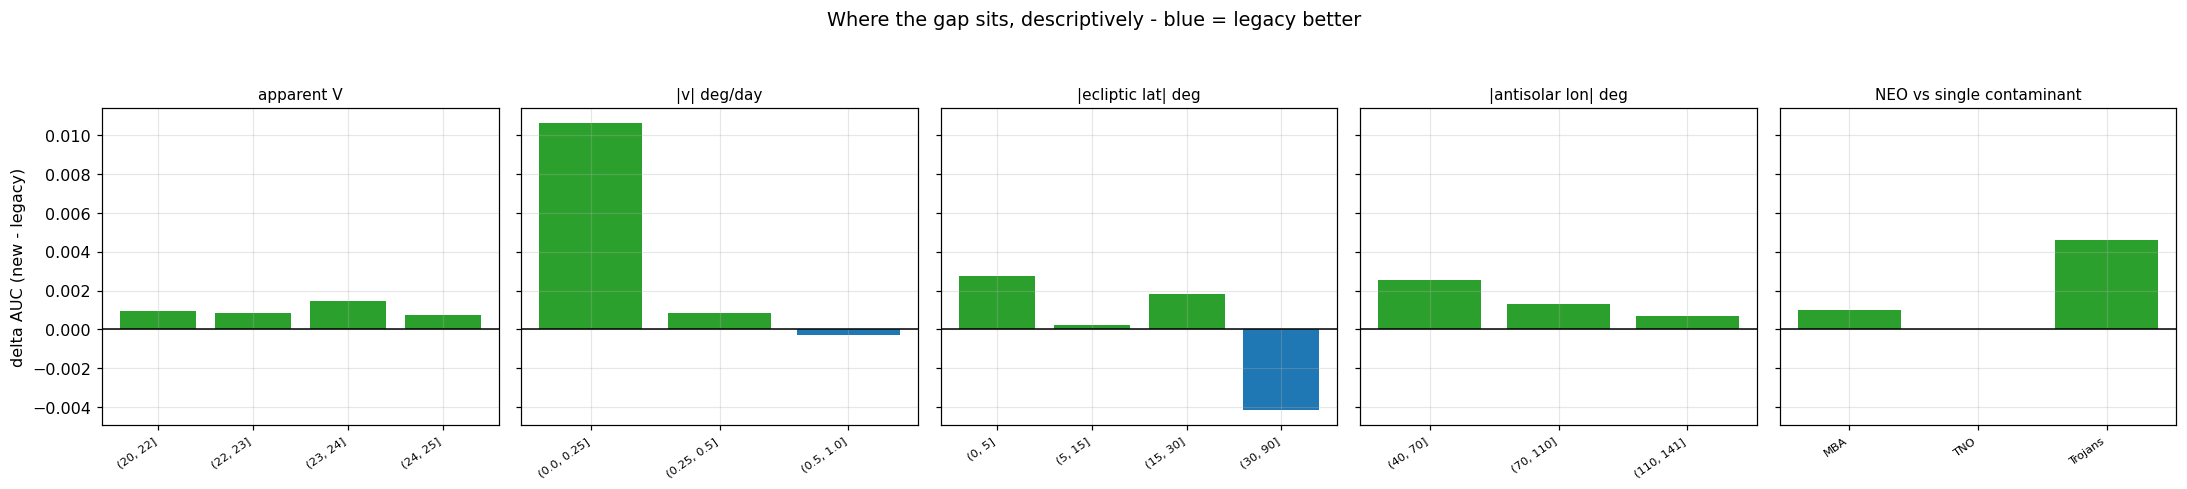

In [29]:
ok = st[st.note==""]
fig, ax = plt.subplots(1, len(strata)+1, figsize=(20,4.2), sharey=True)
for a_, sname in zip(ax, list(strata)+["NEO vs single contaminant"]):
    g = ok[ok.stratum==sname]
    if not len(g): a_.set_title(f"{sname} (none)"); continue
    xp = np.arange(len(g))
    a_.bar(xp, g.delta_auc, color=np.where(g.delta_auc<0,"tab:blue","tab:green"))
    a_.axhline(0,color="k",lw=1)
    a_.set_xticks(xp); a_.set_xticklabels(g.bin, rotation=35, ha="right", fontsize=7.5)
    a_.set_title(sname, fontsize=10)
ax[0].set_ylabel("delta AUC (new - legacy)")
fig.suptitle("Where the gap sits, descriptively - blue = legacy better", y=1.05)
plt.tight_layout(); plt.savefig(FIG/"11_stratification.png", dpi=130, bbox_inches="tight"); plt.show()

## Step 14 — conclusion, constrained to four statements

In [30]:
gm=[]
for uname,u_,yy,ww,scores in (("PAIRED_NEW_LEGACY",U["PAIRED_NEW_LEGACY"],y,w,{"new":sn,"legacy":sl}),
                              ("COMMON_THREEWAY",U["COMMON_THREEWAY"],y2,w2,S2)):
    for nm,sv in scores.items():
        r=dict(universe=uname, classifier=nm, n=int(u_.sum()), auc=auc_w(yy,sv,ww))
        for L in FPR_LIMITS:
            raw,std = pauc_w(yy,sv,ww,L); r[f"pauc_raw@{L}"]=raw; r[f"pauc_std@{L}"]=std
        gm.append(r)
gmt = pd.DataFrame(gm)
print(gmt.to_string(index=False, float_format=lambda z: f"{z:9.5f}"))
gmt.to_csv(OUT/"global_metrics.csv", index=False)

         universe classifier      n       auc  pauc_raw@0.001  pauc_std@0.001  pauc_raw@0.005  pauc_std@0.005  pauc_raw@0.01  pauc_std@0.01  pauc_raw@0.02  pauc_std@0.02  pauc_raw@0.05  pauc_std@0.05
PAIRED_NEW_LEGACY        new 302735   0.93808         0.00056         0.55564         0.00339         0.67751        0.00715        0.71481        0.01496        0.74785        0.03949        0.78979
PAIRED_NEW_LEGACY     legacy 302735   0.93690         0.00061         0.60509         0.00345         0.69051        0.00720        0.72011        0.01498        0.74885        0.03948        0.78951
  COMMON_THREEWAY        new 302666   0.93814         0.00056         0.55581         0.00339         0.67772        0.00715        0.71476        0.01496        0.74780        0.03949        0.78985
  COMMON_THREEWAY     legacy 302666   0.93695         0.00061         0.60528         0.00345         0.69072        0.00720        0.72007        0.01498        0.74880        0.03948        0.78958


In [31]:
sig = bi[bi.excludes_zero & (bi.point<0)]
tie = bi[~bi.excludes_zero]
low = [L for L in FPR_LIMITS
       if bool(bi.loc[bi.metric==f"delta std pAUC (FPR<={L})","excludes_zero"].iloc[0])
       and float(bi.loc[bi.metric==f"delta std pAUC (FPR<={L})","point"].iloc[0])<0]
neg_grid = FPR_GRID[(hi<0)]
print("="*78)
print("1. WHERE")
print(f"   Global AUC difference (new - legacy) = {DELTA_POINT['auc']:+.6f}"
      f"   95% CI [{np.percentile(boot['auc'],2.5):+.6f}, {np.percentile(boot['auc'],97.5):+.6f}]")
if len(neg_grid):
    print(f"   TPR_new < TPR_legacy with the 95% band entirely below zero over FPR "
          f"{neg_grid.min():.2e} to {neg_grid.max():.2e}")
else:
    print("   The 95% band on TPR_new - TPR_legacy does not exclude zero anywhere on the FPR grid.")
print(f"   Pre-declared FPR windows where legacy is significantly better on std pAUC: "
      f"{low if low else 'none'}")
for c in COMPLETENESS_TARGETS:
    row = bi[bi.metric==f"delta precision @ completeness={c}"].iloc[0]
    print(f"   precision @ completeness {c:.0%}: delta {row.point:+.5f}  -> {row.verdict}")
print()
print("2. CONFIDENCE")
print(f"   {len(sig)} of {len(bi)} paired metrics have a 95% interval excluding zero and favour legacy.")
print(f"   {len(tie)} are statistically tied.")
print(f"   Bootstrap: {N_BOOT} paired replicates, seed {SEED}, "
      f"stratified by truth population on identical rows.")
print()
print("3. COVERAGE")
print(f"   Claims rest on PAIRED_NEW_LEGACY: {int(U['PAIRED_NEW_LEGACY'].sum()):,} rows "
      f"= {100*U['PAIRED_NEW_LEGACY'].mean():.2f}% of TEST2, "
      f"{100*U['PAIRED_NEW_LEGACY'][y_all==1].mean():.2f}% of NEOs.")
print("   This is a geometrically selected subset (all four densities must exist in the cell),")
print("   NOT whole-domain performance, and NOT a random subsample.")
print()
print("4. NOT YET WHY")
print("   This notebook locates the difference; it does not explain it. Open hypotheses for the")
print("   mechanism notebook, none tested here:")
for h in ("Gaussian smoothing of the legacy NEO map (sigma=4 px, threshold 10)",
          "k = 150 versus k = 10 and the resulting kNN bandwidth",
          "0.25-mag versus 1-mag bin width, and sample support per cell",
          "legacy cross-magnitude interpolation versus the new single containing slice",
          "legacy nan_to_num zero-filling versus the strict four-density rule",
          "NEO source realization (HIGH 7.4e8 draws) versus the legacy source"):
    print(f"     - {h}")
print("="*78)

1. WHERE
   Global AUC difference (new - legacy) = +0.001188   95% CI [+0.000011, +0.002324]
   TPR_new < TPR_legacy with the 95% band entirely below zero over FPR 1.08e-05 to 1.92e-03
   Pre-declared FPR windows where legacy is significantly better on std pAUC: [0.001, 0.005, 0.01]
   precision @ completeness 20%: delta -0.00353  -> tied
   precision @ completeness 30%: delta -0.01399  -> LEGACY better
   precision @ completeness 40%: delta -0.02880  -> LEGACY better
   precision @ completeness 50%: delta -0.04621  -> LEGACY better

2. CONFIDENCE
   12 of 22 paired metrics have a 95% interval excluding zero and favour legacy.
   8 are statistically tied.
   Bootstrap: 500 paired replicates, seed 20260824, stratified by truth population on identical rows.

3. COVERAGE
   Claims rest on PAIRED_NEW_LEGACY: 302,735 rows = 43.96% of TEST2, 28.12% of NEOs.
   This is a geometrically selected subset (all four densities must exist in the cell),
   NOT whole-domain performance, and NOT a rando

In [32]:
receipt = {
 "notebook": "neomod3_new_vs_legacy_score_regime.ipynb",
 "created_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
 "purpose": "locate where legacy outperforms new; does NOT identify the mechanism",
 "git_commit": git,
 "scorer_seal_sha256": prov["SCORER_SEAL"]["sha256"],
 "map_seal_sha256": seal["map_build_seal_sha256"],
 "inputs": prov,
 "column_roles": COL,
 "weights": {"constant_within_class": const_within, "w_NEO": w_neo, "w_nonNEO": w_non,
             "roc_is_weight_invariant": True,
             "precision_is_weight_dependent": True},
 "universes": {k: int(v.sum()) for k,v in U.items()},
 "fpr_limits": FPR_LIMITS, "fpr_floor_empirical": float(FPR_FLOOR),
 "completeness_targets": COMPLETENESS_TARGETS,
 "contamination_targets": CONTAMINATION_TARGETS,
 "bootstrap": {"replicates": int(N_BOOT), "seed": SEED,
               "unit": "row (parents map 1:1 to tracklets), stratified by truth population",
               "paired": True},
 "headline_reproduced": bool(rep.reproduced.all()),
 "delta_auc_point": float(DELTA_POINT["auc"]),
 "n_metrics_favouring_legacy_significantly": int(len(sig)),
 "n_metrics_tied": int(len(tie)),
 "outputs": sorted(str(x.relative_to(OUT)) for x in OUT.rglob("*") if x.is_file()),
 "no_rescoring": True, "no_map_rebuild": True, "no_threshold_tuning": True,
 "digest2_unmodified": True,
}
(OUT/"RUN_RECEIPT.json").write_text(json.dumps(receipt, indent=2, default=str))
print("wrote", OUT/"RUN_RECEIPT.json")
for f in sorted(OUT.rglob("*")):
    if f.is_file(): print(f"  {f.relative_to(OUT)}  {f.stat().st_size/1e3:.1f} kB")

wrote /mmfs1/gscratch/dirac/ds2004/sorcha/outputs/neomod3_new_vs_legacy_score_regime/RUN_RECEIPT.json
  RUN_RECEIPT.json  4.1 kB
  bootstrap_intervals.csv  3.1 kB
  completeness_operating_points.csv  0.8 kB
  contamination_operating_points.csv  0.4 kB
  coverage.csv  0.7 kB
  figures/01_row_flow.png  132.0 kB
  figures/02_score_distributions.png  122.2 kB
  figures/03_paired_scores.png  311.4 kB
  figures/04_paired_delta.png  64.5 kB
  figures/05_roc_full.png  102.1 kB
  figures/06_roc_lowfpr.png  88.3 kB
  figures/07_roc_logfpr.png  61.3 kB
  figures/08_delta_tpr.png  114.6 kB
  figures/09_completeness_contamination.png  95.7 kB
  figures/10_top_ranked.png  123.6 kB
  figures/11_stratification.png  77.6 kB
  fpr_operating_points.csv  0.6 kB
  global_metrics.csv  1.4 kB
  headline_reproduction.csv  1.3 kB
  pauc_convention.csv  0.4 kB
  row_flow.csv  0.4 kB
  score_quantiles.csv  1.0 kB
  stratification.csv  1.9 kB
